In [1]:
#LOAD MODULES
import tensorflow as tf

assert tf.__version__.startswith('2')
from os import listdir
import numpy as np
#import segmentation_models as sm
import cv2

#sm.set_framework('tf.keras')
#sm.framework()
from PIL import Image
import tensorflow as tf
from scipy import ndimage
import pandas as pd

import copy
import tensorflow_addons as tfa
import matplotlib.pyplot as plt
from keras import backend as K
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import random
import copy

import openpyxl
import sys
import os

import traceback
import keras

model_path = "model_further_6.keras"
#reconstructed_model = keras.models.load_model(path)

resize_coeff=1
patch_size = (256, 256)
const_outside = 0.626



/Users/anna.lisitsyna/venvs/tf/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [2]:
c1_temp = {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-1/1.png': (965,
  950),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-1/2.png': (990,
  925),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-1/3.png': (955,
  960),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-1/4.png': (1045,
  930),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-2/1.png': (935,
  750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-2/2.png': (965,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-2/3.png': (1010,
  825),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-2/4.png': (980,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-3/1.png': (892,
  775),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-3/2.png': (952,
  777),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-3/3.png': (990,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-3/4.png': (937,
  812),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-4/1.png': (1002,
  884),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-4/2.png': (910,
  837),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-4/3.png': (967,
  815),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-4/4.png': (920,
  820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-5/1.png': (975,
  715),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-5/2.png': (915,
  757),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-5/3.png': (990,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-5/4.png': (896,
  817),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-6/1.png': (1035,
  927),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-6/2.png': (940,
  895),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-6/3.png': (1020,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-6/4.png': (893,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-1/1.png': (980,
  876),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-1/2.png': (1105,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-1/3.png': (1143,
  970),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-1/4.png': (1065,
  973),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-2/1.png': (850,
  862),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-2/2.png': (915,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-2/3.png': (995,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-2/4.png': (910,
  917),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-3/1.png': (735,
  760),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-3/2.png': (785,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-3/3.png': (960,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-3/4.png': (965,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-4/1.png': (930,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-4/2.png': (970,
  820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-4/3.png': (1060,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-4/4.png': (980,
  890),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-5/1.png': (840,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-5/2.png': (890,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-5/3.png': (1055,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-5/4.png': (1180,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-6/1.png': (910,
  750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-6/2.png': (950,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-6/3.png': (1100,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-6/4.png': (1140,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-7/1.png': (975,
  895),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-7/2.png': (1055,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-7/3.png': (1225,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-7/4.png': (1225,
  835),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-8/1.png': (970,
  1000),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-8/2.png': (1050,
  965),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-8/3.png': (1080,
  920),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-8/4.png': (970,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-9/1.png': (1045,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-9/2.png': (1140,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-9/3.png': (1165,
  815),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-9/4.png': (1110,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-10/1.png': (925,
  995),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-10/2.png': (1140,
  940),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-10/3.png': (1120,
  875),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-10/4.png': (930,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-1/1.png': (975,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-1/2.png': (975,
  820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-1/3.png': (947,
  820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-1/4.png': (1117,
  797),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-2/1.png': (987,
  865),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-2/2.png': (982,
  855),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-2/3.png': (1022,
  825),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-2/4.png': (1105,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-3/1.png': (990,
  820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-3/2.png': (1015,
  815),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-3/3.png': (1010,
  817),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-3/4.png': (1112,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-4/1.png': (875,
  827),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-4/2.png': (892,
  835),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-4/3.png': (930,
  820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-4/4.png': (980,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-5/1.png': (1030,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-5/2.png': (985,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-5/3.png': (915,
  855),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-5/4.png': (977,
  875),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-6/1.png': (895,
  905),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-6/2.png': (970,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-6/3.png': (995,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-6/4.png': (1027,
  807),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-7/1.png': (900,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-7/2.png': (810,
  815),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-7/3.png': (955,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-7/4.png': (920,
  890),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-8/1.png': (990,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-8/2.png': (885,
  885),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-8/3.png': (1025,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-8/4.png': (975,
  895),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-9/1.png': (875,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-9/2.png': (780,
  740),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-9/3.png': (910,
  735),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-9/4.png': (852,
  747),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-10/1.png': (865,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-10/2.png': (790,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-10/3.png': (902,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-10/4.png': (900,
  760),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-11/1.png': (940,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-11/2.png': (910,
  865),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-11/3.png': (940,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-11/4.png': (975,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-1/1.png': (1070,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-1/2.png': (1075,
  820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-1/3.png': (1045,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-1/4.png': (1040,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-2/1.png': (1032,
  725),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-2/2.png': (1052,
  717),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-2/3.png': (1025,
  725),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-2/4.png': (1035,
  705),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-3/1.png': (1010,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-3/2.png': (1040,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-3/3.png': (987,
  755),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-3/4.png': (1005,
  720),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-4/1.png': (985,
  895),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-4/2.png': (1017,
  912),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-4/3.png': (970,
  902),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-4/4.png': (980,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-5/1.png': (980,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-5/2.png': (1010,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-5/3.png': (965,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-5/4.png': (970,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-6/1.png': (1060,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-6/2.png': (995,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-6/3.png': (970,
  835),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-6/4.png': (960,
  775),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-7/1.png': (1005,
  740),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-7/2.png': (1015,
  760),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-7/3.png': (1060,
  785),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-7/4.png': (1040,
  785),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-8/1.png': (1005,
  700),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-8/2.png': (980,
  710),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-8/3.png': (1005,
  690),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-8/4.png': (980,
  720),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-9/1.png': (1000,
  742),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-9/2.png': (1000,
  730),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-9/3.png': (1000,
  730),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-9/4.png': (910,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-10/1.png': (990,
  725),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-10/2.png': (1000,
  705),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-10/3.png': (980,
  670),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-10/4.png': (900,
  685),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-11/1.png': (975,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-11/2.png': (980,
  875),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-11/3.png': (965,
  855),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-11/4.png': (780,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-12/1.png': (950,
  925),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-12/2.png': (955,
  900),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-12/3.png': (975,
  855),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-12/4.png': (735,
  795),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-1/1.png': (890,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-1/2.png': (942,
  920),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-1/3.png': (965,
  835),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-1/4.png': (930,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-2/1.png': (882,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-2/2.png': (925,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-2/3.png': (930,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-2/4.png': (1040,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-3/1.png': (1010,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-3/2.png': (860,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-3/3.png': (950,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-3/4.png': (870,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-4/1.png': (955,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-4/2.png': (900,
  820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-4/3.png': (900,
  750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-4/4.png': (920,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-5/1.png': (1035,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-5/2.png': (1010,
  920),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-5/3.png': (910,
  865),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-5/4.png': (1000,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-6/1.png': (970,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-6/2.png': (1020,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-6/3.png': (910,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-6/4.png': (960,
  825),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-7/1.png': (840,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-7/2.png': (890,
  820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-7/3.png': (770,
  847),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-7/4.png': (840,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-8/1.png': (835,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-8/2.png': (920,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-8/3.png': (840,
  795),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-8/4.png': (840,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-9/1.png': (840,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-9/2.png': (890,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-9/3.png': (890,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-9/4.png': (930,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-10/1.png': (800,
  820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-10/2.png': (790,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-10/3.png': (860,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-10/4.png': (910,
  740),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-11/1.png': (830,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-11/2.png': (910,
  940),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-11/3.png': (880,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-11/4.png': (940,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-12/1.png': (840,
  900),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-12/2.png': (830,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-12/3.png': (830,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-12/4.png': (870,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-1/1.png': (1015,
  895),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-1/2.png': (920,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-1/3.png': (940,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-1/4.png': (1050,
  755),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-2/1.png': (970,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-2/2.png': (890,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-2/3.png': (900,
  890),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-2/4.png': (1040,
  890),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-3/1.png': (880,
  930),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-3/2.png': (840,
  940),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-3/3.png': (850,
  940),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-3/4.png': (1000,
  905),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-4/1.png': (830,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-4/2.png': (800,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-4/3.png': (815,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-4/4.png': (1050,
  730),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-5/1.png': (750,
  920),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-5/2.png': (705,
  885),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-5/3.png': (770,
  885),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-5/4.png': (1000,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-6/1.png': (940,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-6/2.png': (890,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-6/3.png': (730,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-6/4.png': (1000,
  705),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-7/1.png': (950,
  775),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-7/2.png': (950,
  865),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-7/3.png': (950,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-7/4.png': (1090,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-8/1.png': (925,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-8/2.png': (875,
  775),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-8/3.png': (930,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-8/4.png': (1145,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-9/1.png': (975,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-9/2.png': (905,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-9/3.png': (1040,
  940),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-9/4.png': (1140,
  930),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-10/1.png': (1040,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-10/2.png': (960,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-10/3.png': (1000,
  760),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-10/4.png': (1160,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-11/1.png': (1080,
  755),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-11/2.png': (950,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-11/3.png': (960,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-11/4.png': (1120,
  755),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-12/1.png': (1110,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-12/2.png': (1100,
  890),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-12/3.png': (1030,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-12/4.png': (1060,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-1/1.png': (980,
  740),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-1/2.png': (1020,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-1/3.png': (1010,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-1/4.png': (1000,
  815),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-2/1.png': (950,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-2/2.png': (990,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-2/3.png': (1010,
  775),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-2/4.png': (1070,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-3/1.png': (985,
  750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-3/2.png': (965,
  750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-3/3.png': (1070,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-3/4.png': (1055,
  815),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-4/1.png': (1090,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-4/2.png': (1090,
  785),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-4/3.png': (1060,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-4/4.png': (1100,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-5/1.png': (1010,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-5/2.png': (1070,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-5/3.png': (950,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-5/4.png': (1060,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-6/1.png': (1030,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-6/2.png': (1010,
  855),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-6/3.png': (1040,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-6/4.png': (1035,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-7/1.png': (920,
  820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-7/2.png': (940,
  795),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-7/3.png': (1080,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-7/4.png': (1020,
  720),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-8/1.png': (850,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-8/2.png': (940,
  765),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-8/3.png': (830,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-8/4.png': (980,
  730),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-9/1.png': (830,
  755),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-9/2.png': (905,
  745),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-9/3.png': (800,
  755),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-9/4.png': (905,
  740),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-10/1.png': (880,
  755),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-10/2.png': (980,
  765),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-10/3.png': (915,
  715),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-10/4.png': (870,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-11/1.png': (705,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-11/2.png': (835,
  745),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-11/3.png': (910,
  700),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-11/4.png': (805,
  750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-12/1.png': (690,
  847),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-12/2.png': (860,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-12/3.png': (840,
  730),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-12/4.png': (805,
  710),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-1/1.png': (1070,
  865),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-1/2.png': (1155,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-1/3.png': (1223,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-1/4.png': (875,
  815),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-2/1.png': (1080,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-2/2.png': (0,
  0),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-2/3.png': (1210,
  750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-2/4.png': (915,
  715),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-3/1.png': (935,
  720),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-3/2.png': (1060,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-3/3.png': (1190,
  785),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-3/4.png': (1170,
  750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-5/1.png': (900,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-5/2.png': (770,
  855),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-5/3.png': (915,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-5/4.png': (945,
  750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-6/1.png': (985,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-6/2.png': (910,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-6/3.png': (1045,
  795),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-6/4.png': (1060,
  720),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-7/1.png': (1075,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-7/2.png': (1065,
  965),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-7/3.png': (1155,
  950),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-7/4.png': (1185,
  925),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-8/1.png': (1125,
  995),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-8/2.png': (1090,
  1000),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-8/3.png': (1210,
  985),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-8/4.png': (960,
  925),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-9/1.png': (1080,
  990),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-9/2.png': (1165,
  730),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-9/3.png': (1170,
  960),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-9/4.png': (1115,
  905),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-10/1.png': (1075,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-10/2.png': (0,
  0),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-10/3.png': (1150,
  960),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-10/4.png': (1185,
  922),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-11/1.png': (1085,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-11/2.png': (1010,
  760),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-11/3.png': (1110,
  995),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-11/4.png': (1145,
  965),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-12/1.png': (1085,
  940),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-12/2.png': (0,
  0),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-12/3.png': (1075,
  905),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-12/4.png': (1135,
  870), 
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-1/1.png':(820, 805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-1/2.png':(760, 800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-1/3.png':(860, 800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-1/4.png':(860, 850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-2/1.png':(750, 750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-2/2.png':(770, 770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-2/3.png':(930, 750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-2/4.png':(840, 820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-3/1.png':(720, 710),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-3/2.png':(800, 840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-3/3.png':(1000, 830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-3/4.png':(940, 850),             
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-4/1.png':(860, 820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-4/2.png':(780, 820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-4/3.png':(1150, 1000),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-4/4.png':(1030, 960),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-5/1.png':(765, 750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-5/2.png':(870, 900),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-5/3.png':(1020, 860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-5/4.png':(1065, 860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-6/1.png':(825, 835),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-6/2.png':(820, 855),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-6/3.png':(1005, 780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-6/4.png':(980, 865),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-7/1.png':(925, 875),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-7/2.png':(955, 810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-7/3.png':(1045, 750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-7/4.png':(1030, 900),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-8/1.png':(1075, 870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-8/2.png':(1085, 820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-8/3.png':(1200, 970),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-8/4.png':(1135, 930),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-9/1.png':(985, 1000),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-9/2.png':(925, 950),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-9/3.png':(1000, 940),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-9/4.png':(1015, 910),             
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-10/1.png':(810, 975),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-10/2.png':(955, 875),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-10/3.png':(1015, 890),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-10/4.png':(1060, 825),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-11/1.png':(780, 990),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-11/2.png':(890, 940),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-11/3.png':(1005, 900),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-11/4.png':(990, 810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-12/1.png':(820, 910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-12/2.png':(820, 830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-12/3.png':(900, 770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-12/4.png':(870, 690)}


In [3]:
c2_temp = {'/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-1/1.png': (977,
  978),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-1/2.png': (975,
  930),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-1/3.png': (945,
  965),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-1/4.png': (1040,
  930),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-2/1.png': (937,
  748),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-2/2.png': (955,
  775),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-2/3.png': (1000,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-2/4.png': (985,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-3/1.png': (888,
  798),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-3/2.png': (942,
  795),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-3/3.png': (998,
  785),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-3/4.png': (953,
  838),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-4/1.png': (1015,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-4/2.png': (947,
  832),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-4/3.png': (970,
  795),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-4/4.png': (945,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-5/1.png': (985,
  720),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-5/2.png': (904,
  753),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-5/3.png': (985,
  785),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-5/4.png': (890,
  813),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-6/1.png': (1022,
  930),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-6/2.png': (945,
  890),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-6/3.png': (1035,
  872),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220617/profilometer/before/4-1-6/4.png': (930,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-1/1.png': (970,
  884),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-1/2.png': (1115,
  920),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-1/3.png': (1142,
  972),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-1/4.png': (1073,
  965),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-2/1.png': (835,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-2/2.png': (915,
  895),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-2/3.png': (985,
  855),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-2/4.png': (905,
  917),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-3/1.png': (730,
  760),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-3/2.png': (790,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-3/3.png': (950,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-3/4.png': (967,
  912),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-4/1.png': (920,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-4/2.png': (975,
  820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-4/3.png': (1070,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-4/4.png': (980,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-5/1.png': (830,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-5/2.png': (890,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-5/3.png': (1055,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-5/4.png': (1170,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-6/1.png': (910,
  755),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-6/2.png': (950,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-6/3.png': (1100,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-6/4.png': (1130,
  820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-7/1.png': (980,
  895),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-7/2.png': (1065,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-7/3.png': (1200,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-7/4.png': (1225,
  855),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-8/1.png': (950,
  990),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-8/2.png': (1060,
  950),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-8/3.png': (1095,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-8/4.png': (960,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-9/1.png': (1040,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-9/2.png': (1140,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-9/3.png': (1165,
  815),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-9/4.png': (1100,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-10/1.png': (910,
  1000),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-10/2.png': (1145,
  935),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-10/3.png': (1115,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-3-10/4.png': (920,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-1/1.png': (975,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-1/2.png': (975,
  820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-1/3.png': (942,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-1/4.png': (1115,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-2/1.png': (985,
  865),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-2/2.png': (967,
  837),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-2/3.png': (1030,
  825),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-2/4.png': (1120,
  835),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-3/1.png': (990,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-3/2.png': (1015,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-3/3.png': (1010,
  817),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-3/4.png': (1110,
  802),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-4/1.png': (875,
  827),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-4/2.png': (892,
  835),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-4/3.png': (945,
  817),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-4/4.png': (987,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-5/1.png': (1032,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-5/2.png': (985,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-5/3.png': (920,
  847),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-5/4.png': (985,
  872),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-6/1.png': (905,
  905),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-6/2.png': (968,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-6/3.png': (1000,
  835),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-6/4.png': (1020,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-7/1.png': (890,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-7/2.png': (805,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-7/3.png': (955,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-7/4.png': (915,
  885),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-8/1.png': (995,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-8/2.png': (885,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-8/3.png': (1025,
  875),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-8/4.png': (980,
  890),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-9/1.png': (865,
  795),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-9/2.png': (780,
  745),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-9/3.png': (910,
  730),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-9/4.png': (850,
  740),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-10/1.png': (870,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-10/2.png': (790,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-10/3.png': (890,
  797),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-10/4.png': (900,
  760),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-11/1.png': (945,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-11/2.png': (907,
  872),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-11/3.png': (935,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220823/profilometer/before/2-2-11/4.png': (975,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-1/1.png': (1060,
  857),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-1/2.png': (1070,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-1/3.png': (1030,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-1/4.png': (1025,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-2/1.png': (1022,
  725),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-2/2.png': (1045,
  727),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-2/3.png': (1015,
  735),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-2/4.png': (1025,
  710),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-3/1.png': (1000,
  817),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-3/2.png': (1017,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-3/3.png': (980,
  755),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-3/4.png': (995,
  730),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-4/1.png': (987,
  915),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-4/2.png': (1012,
  925),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-4/3.png': (965,
  907),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-4/4.png': (960,
  905),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-5/1.png': (980,
  895),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-5/2.png': (995,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-5/3.png': (955,
  865),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-5/4.png': (970,
  855),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-6/1.png': (1035,
  915),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-6/2.png': (990,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-6/3.png': (960,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-6/4.png': (955,
  785),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-7/1.png': (1005,
  745),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-7/2.png': (1025,
  755),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-7/3.png': (1065,
  775),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-7/4.png': (1050,
  775),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-8/1.png': (1000,
  690),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-8/2.png': (1030,
  695),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-8/3.png': (1005,
  690),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-8/4.png': (1030,
  695),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-9/1.png': (1015,
  722),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-9/2.png': (1010,
  730),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-9/3.png': (1010,
  730),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-9/4.png': (915,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-10/1.png': (1005,
  725),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-10/2.png': (990,
  685),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-10/3.png': (980,
  670),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-10/4.png': (900,
  690),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-11/1.png': (965,
  885),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-11/2.png': (980,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-11/3.png': (965,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-11/4.png': (780,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-12/1.png': (950,
  920),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-12/2.png': (965,
  900),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-12/3.png': (975,
  855),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-3-12/4.png': (735,
  795),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-1/1.png': (890,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-1/2.png': (942,
  915),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-1/3.png': (950,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-1/4.png': (930,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-2/1.png': (882,
  905),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-2/2.png': (917,
  872),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-2/3.png': (930,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-2/4.png': (1040,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-3/1.png': (1000,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-3/2.png': (860,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-3/3.png': (950,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-3/4.png': (870,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-4/1.png': (955,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-4/2.png': (900,
  820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-4/3.png': (900,
  750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-4/4.png': (920,
  835),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-5/1.png': (1035,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-5/2.png': (1010,
  920),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-5/3.png': (910,
  865),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-5/4.png': (980,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-6/1.png': (970,
  905),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-6/2.png': (1020,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-6/3.png': (910,
  875),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-6/4.png': (960,
  825),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-7/1.png': (840,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-7/2.png': (900,
  815),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-7/3.png': (770,
  847),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-7/4.png': (840,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-8/1.png': (835,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-8/2.png': (920,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-8/3.png': (840,
  795),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-8/4.png': (840,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-9/1.png': (840,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-9/2.png': (890,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-9/3.png': (890,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-9/4.png': (930,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-10/1.png': (800,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-10/2.png': (790,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-10/3.png': (860,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-10/4.png': (900,
  740),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-11/1.png': (830,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-11/2.png': (920,
  950),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-11/3.png': (880,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-11/4.png': (950,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-12/1.png': (840,
  900),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-12/2.png': (830,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-12/3.png': (830,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-4-12/4.png': (870,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-1/1.png': (1015,
  895),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-1/2.png': (920,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-1/3.png': (940,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-1/4.png': (1050,
  755),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-2/1.png': (970,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-2/2.png': (870,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-2/3.png': (890,
  890),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-2/4.png': (1040,
  890),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-3/1.png': (880,
  930),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-3/2.png': (840,
  940),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-3/3.png': (850,
  940),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-3/4.png': (1000,
  905),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-4/1.png': (830,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-4/2.png': (800,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-4/3.png': (815,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-4/4.png': (1050,
  730),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-5/1.png': (750,
  920),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-5/2.png': (705,
  885),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-5/3.png': (770,
  885),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-5/4.png': (980,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-6/1.png': (930,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-6/2.png': (880,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-6/3.png': (730,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-6/4.png': (990,
  715),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-7/1.png': (950,
  775),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-7/2.png': (950,
  865),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-7/3.png': (940,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-7/4.png': (1090,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-8/1.png': (925,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-8/2.png': (875,
  775),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-8/3.png': (930,
  760),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-8/4.png': (1145,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-9/1.png': (975,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-9/2.png': (905,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-9/3.png': (1040,
  940),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-9/4.png': (1140,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-10/1.png': (1040,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-10/2.png': (970,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-10/3.png': (1000,
  760),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-10/4.png': (1160,
  880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-11/1.png': (1080,
  755),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-11/2.png': (950,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-11/3.png': (960,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-11/4.png': (1120,
  755),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-12/1.png': (1110,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-12/2.png': (1100,
  890),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-12/3.png': (1030,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-5-12/4.png': (1060,
  855),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-1/1.png': (980,
  740),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-1/2.png': (1020,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-1/3.png': (1010,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-1/4.png': (1000,
  815),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-2/1.png': (950,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-2/2.png': (1000,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-2/3.png': (1010,
  775),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-2/4.png': (1070,
  845),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-3/1.png': (985,
  750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-3/2.png': (965,
  760),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-3/3.png': (1080,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-3/4.png': (1055,
  815),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-4/1.png': (1090,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-4/2.png': (1090,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-4/3.png': (1060,
  855),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-4/4.png': (1100,
  870),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-5/1.png': (1010,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-5/2.png': (1070,
  835),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-5/3.png': (950,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-5/4.png': (1060,
  860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-6/1.png': (1030,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-6/2.png': (1010,
  855),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-6/3.png': (1040,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-6/4.png': (1030,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-7/1.png': (920,
  820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-7/2.png': (950,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-7/3.png': (1080,
  780),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-7/4.png': (1020,
  720),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-8/1.png': (850,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-8/2.png': (950,
  775),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-8/3.png': (830,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-8/4.png': (980,
  710),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-9/1.png': (830,
  755),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-9/2.png': (920,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-9/3.png': (815,
  775),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-9/4.png': (915,
  760),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-10/1.png': (880,
  755),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-10/2.png': (980,
  765),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-10/3.png': (915,
  715),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-10/4.png': (840,
  800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-11/1.png': (705,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-11/2.png': (855,
  750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-11/3.png': (850,
  730),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-11/4.png': (805,
  775),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-12/1.png': (700,
  855),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-12/2.png': (860,
  810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-12/3.png': (840,
  730),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220719/profilometer/before/4-6-12/4.png': (815,
  720),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-1/1.png': (1070,
  865),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-1/2.png': (1140,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-1/3.png': (1223,
  815),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-1/4.png': (875,
  835),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-2/1.png': (1075,
  865),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-2/2.png': (0,
  0),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-2/3.png': (1215,
  755),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-2/4.png': (940,
  715),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-3/1.png': (935,
  730),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-3/2.png': (1060,
  850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-3/3.png': (1190,
  785),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-3/4.png': (1180,
  730),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-5/1.png': (890,
  900),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-5/2.png': (770,
  855),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-5/3.png': (915,
  805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-5/4.png': (930,
  740),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-6/1.png': (990,
  830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-6/2.png': (915,
  840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-6/3.png': (1050,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-6/4.png': (1060,
  710),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-7/1.png': (1080,
  930),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-7/2.png': (1065,
  965),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-7/3.png': (1155,
  950),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-7/4.png': (1190,
  920),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-8/1.png': (1120,
  1000),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-8/2.png': (1090,
  1000),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-8/3.png': (1210,
  985),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-8/4.png': (0,
  0),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-9/1.png': (1080,
  990),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-9/2.png': (1160,
  750),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-9/3.png': (1175,
  950),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-9/4.png': (1140,
  905),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-10/1.png': (1075,
  790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-10/2.png': (0,
  0),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-10/3.png': (1100,
  990),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-10/4.png': (1132,
  967),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-11/1.png': (1082,
  785),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-11/2.png': (1005,
  770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-11/3.png': (1140,
  965),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-11/4.png': (1180,
  920),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-12/1.png': (1085,
  940),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-12/2.png': (0,
  0),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-12/3.png': (1075,
  910),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220906/profilometer/before/2-5-12/4.png': (1120,
  880), 
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-1/1.png':(845, 825),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-1/2.png':(750, 805),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-1/3.png':(865, 825),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-1/4.png':(845, 825),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-2/1.png':(785, 815),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-2/2.png':(775, 815),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-2/3.png':(910, 745),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-2/4.png':(830, 820),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-3/1.png':(705, 710),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-3/2.png':(825, 710),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-3/3.png':(980, 810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-3/4.png':(980, 850),             
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-4/1.png':(900, 830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-4/2.png':(790, 770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-4/3.png':(1130, 990),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-4/4.png':(1070, 930),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-5/1.png':(830, 810),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-5/2.png':(870, 850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-5/3.png':(1025, 860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-5/4.png':(1025, 860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-6/1.png':(820, 830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-6/2.png':(810, 840),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-6/3.png':(1000, 770),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-6/4.png':(1020, 850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-7/1.png':(960, 860),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-7/2.png':(960, 800),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-7/3.png':(1050, 900),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-7/4.png':(1050, 900),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-8/1.png':(1080, 880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-8/2.png':(1080, 990),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-8/3.png':(1200, 990),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-8/4.png':(1180, 990),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-9/1.png':(1020, 990),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-9/2.png':(910, 960),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-9/3.png':(980, 950),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-9/4.png':(1000, 930),             
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-10/1.png':(830, 960),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-10/2.png':(930, 900),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-10/3.png':(1020, 890),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-10/4.png':(1020, 880),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-11/1.png':(840, 970),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-11/2.png':(870, 950),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-11/3.png':(970, 920),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-11/4.png':(950, 830),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-12/1.png':(840, 900),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-12/2.png':(700, 850),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-12/3.png':(850, 790),
 '/Users/anna.lisitsyna/Documents/Corrosion estimation/Pics//20220919/profilometer/before/2-4-12/4.png':(870, 690)}

In [4]:
#FUNCTIONS FOR READING ORIGINAL FILES FOR HEATMAP AND PROFILOMETER

def interp(data, method=None, filename=None, resize_coeff=None, pad=((0, 0), (0, 0))):
    try:
        mask = np.isnan(data)
        if method is None:
            data[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), data[~mask])
            if resize_coeff is not None:
                data = np.pad(data, mode='constant', pad_width=pad, constant_values=0)
                data = ndimage.zoom(data, 1.0 / resize_coeff)
    except Exception as e:
        print(f"!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!The problem is {e}")
        print(f"The type of data is {type(data)}, and data itself is {data} in file {filename}")
    return np.expand_dims(data, axis=2) 


def resize_profilometer(filepath, resize_coeff, greysc=False):
    pic_profilometer_temp = Image.fromarray(cv2.imread(filepath))#[:1664, :1792])
    width_temp, height_temp = pic_profilometer_temp.size
    pic_profilometer_temp= pic_profilometer_temp.resize(
        (int(width_temp / resize_coeff), int(height_temp / resize_coeff)))
    pic_profilometer_temp = np.array(pic_profilometer_temp)
    return pic_profilometer_temp / 255

def load_scanner(filepath, resize_coeff=1, greysc=False):
    im = Image.open(filepath)
    im = np.array(im)
    im1 = np.array(im)[480:2930, 4860:7310]
    im2 = np.array(im)[480:2930, 9370:9370+2450]
    im3 = np.array(im)[480:2930, 13900:13900+2450]
    im4 = np.array(im)[480:2930, 18430:18430+2450]
    return [im1, im2, im3, im4]

In [5]:
def ncc(data0, data1):
    """
    normalized cross-correlation coefficient between two data sets

    Parameters
    ----------
    data0, data1 :  numpy arrays of same size
    """
    return (1.0/(data0.size-1)) * np.sum(data0*data1)

In [6]:
#METRICS AND LOSSES

#REVERSE HUBER WITH ADJUSTABLE THRESHOLD
def RevHub_loss(labels, predictions, c = 0.1):
    if labels is None:
        raise ValueError("labels must not be None.")
    if predictions is None:
        raise ValueError("predictions must not be None.")

    # Make sure shape do match
    predictions.get_shape().assert_is_compatible_with(labels.get_shape())

    # Get absolute error for each pixel in batch
    abs_error = tf.abs(tf.subtract(predictions, labels), name='abs_error')
    c = c * tf.reduce_max(abs_error)
    RevHub_loss = tf.where(abs_error <= c,
                          abs_error,
                          (tf.square(abs_error) + tf.square(c)) / (2 * c))

    loss = tf.reduce_mean(RevHub_loss)

    return loss

def combined_loss(target, output, w=[1, 100]):
    return (w[0]*volume_loss_difference(target, output)+w[1]*RevHub_loss(target, output))/2

def volume_loss_difference(target_img, output_img):
    max_val = 0.1
    min_val = -0.03
    output_denormalised = output_img*(max_val-min_val)+min_val
    target_denormalised = target_img*(max_val-min_val)+min_val
    pixsize = (7.406, 7.406, 1)

    vol_tar = tf.reduce_sum(tf.abs(target_denormalised), axis=[1, 2, 3])* pixsize[0] * resize_coeff * pixsize[1] * resize_coeff * pixsize[2] * resize_coeff /(2*10**6)
    vol_out = tf.reduce_sum(tf.abs(output_denormalised), axis=[1, 2, 3]) * pixsize[0] * resize_coeff * pixsize[1] * resize_coeff * pixsize[2] * resize_coeff / (2*10**6)

    print("Vol_tar is {} and vol_out is {}".format(vol_tar, vol_out))
    vol_loss_diff = tf.divide(tf.abs(vol_tar - vol_out), vol_tar+0.0001) * 100
    print("Vol_loss_diff is {} ".format(vol_loss_diff))
    return tf.reduce_mean(vol_loss_diff)

In [7]:
#FUNCTIONS FOR PATCHES CUTTING AND RECONSTRUCTION (overlap 50%)

def patches(img, patch_size=patch_size, step=128):
    res_patches = []
    x_tops = []
    y_tops = []
    if step is None:
        for i in range(1, img.shape[0] // patch_size[0] * img.shape[1] // patch_size[1]-1):
            x_num = i // (img.shape[0] // patch_size[0])
            y_num = i % (img.shape[0] // patch_size[0])
            patch_temp = img[
                         patch_size[1] * y_num:patch_size[1] * y_num + patch_size[1],
                         patch_size[0] * x_num:patch_size[0] * x_num + patch_size[0]]
            if patch_temp.shape[0] == patch_size[0] and patch_temp.shape[1] == patch_size[1]:
                res_patches.append(patch_temp)
    else:
        x_top = 0
        y_top = 0
        i =0
        while y_top <= img.shape[1] - patch_size[1]:
            while x_top<= img.shape[0]-patch_size[0]:
                patch_temp = img[
                             y_top:y_top + patch_size[1],
                             x_top:x_top + patch_size[0]]
                if patch_temp.shape[0] == patch_size[0] and patch_temp.shape[1] == patch_size[1]:
                    res_patches.append(patch_temp)
                x_tops.append(x_top)
                y_tops.append(y_top)
                i=i+1
                x_top = x_top+step
            x_top = 0
            y_top = y_top + step
    return res_patches

def patches_overlap_reconstruct(preds, orig_heat, patch_size=patch_size, step=128):
    nums_matrix = np.full((orig_heat.shape[0], orig_heat.shape[1]), 0)
    vals_matrix = np.full((orig_heat.shape[0], orig_heat.shape[1]), 0.0)
    for i in range(len(preds)):
        x_top = step*(i % ((orig_heat.shape[1]-patch_size[1]) // step+1))
        y_top = step*(i // ((orig_heat.shape[0]-patch_size[0])// step+1))
        nums_matrix[y_top:y_top + patch_size[1],
                             x_top:x_top + patch_size[0]] += 1
        vals_matrix[y_top:y_top + patch_size[1], x_top:x_top + patch_size[0]] += preds[i][:, :, 0]
    vals_matrix = vals_matrix/np.clip(nums_matrix, a_min=1, a_max=len(preds))
    return vals_matrix

In [8]:
def ncc(data0, data1):
    """
    normalized cross-correlation coefficient between two data sets

    Parameters
    ----------
    data0, data1 :  numpy arrays of same size
    """
    return (1.0/(data0.size-1)) * np.sum(data0*data1)

In [9]:
#FUNCTION FOR RELATIVE MEAN ERROR
def relative_mean_err(original, target, val=const_outside):
    mask_supertemp  = create_circular_mask(original.shape[0], original.shape[1], center=(original.shape[1]/2, original.shape[1]/2), radius=670)
    diff = abs(original[np.logical_and(mask_supertemp, target!=0)]-target[np.logical_and(mask_supertemp, target!=0)])
    nonzero_heat = abs(target[np.logical_and(mask_supertemp, target!=0)])
    return np.median(diff/nonzero_heat)*100

In [10]:
#FUNCTION FOR VOLUME LOSS

def get_weight_loss(vol_loss, dens = 1.78):
    return vol_loss*dens

def get_inhibition_efficiency(weight_loss, NaCl_weight_loss):
    return 1 - 1.0*weight_loss/NaCl_weight_loss

def get_volume(hmap, pixsize=(7.406, 7.406, 1)):
    h, w = hmap.shape[:2]
    mask = create_circular_mask(h, w)
    masked_img = hmap.copy()
    masked_img[~mask] = 0
    #all_hmap = abs(masked_img)
    all_hmap = masked_img#(np.clip(masked_img, None, 0))
    all_hmap = all_hmap.flatten()
    #vol = abs(sum(abs(all_hmap[all_hmap<0]))-sum(all_hmap[all_hmap>0])) * pixsize[0] * pixsize[1] * pixsize[2] / (2*10**6)
    vol = sum(abs(all_hmap[all_hmap<0])) * pixsize[0] * pixsize[1] * pixsize[2] / (10**6)
    return vol

def get_full_volume(hmap, pixsize=(7.406, 7.406, 1)):
    all_hmap = hmap
    all_hmap = all_hmap.flatten()
    vol = sum(abs(all_hmap[all_hmap<0])) * pixsize[0] * pixsize[1] * pixsize[2] / (10**6)
    return vol

def remove_ticks(ax):
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)


def plot_sample_evaluation(prof, heat, preds, filename_temp):
    vol_losses = []
    maes = []
    rel_maes = []
    for i in range(len(preds)):
        vol_losses.append(get_volume(return_back(preds[i])))
        maes.append(mean_absolute_error(heat.flatten(), preds[i].flatten()))
        rel_maes.append(relative_mean_err(heat, preds[i]))
    vol_loss_gt = get_volume(return_back(heat))
    
    fig, axes = plt.subplots(nrows=1, ncols=len(preds)+2, figsize=(18, 9))
    
    
    fig.suptitle("Prediction for {0} \nVolume loss (predicted): {1} \nVolume loss (on GT): {2}".format(filename_temp,  vol_losses, vol_loss_gt))
    axes[0].set_title("Original input", fontdict={'fontsize': 10,
                                                  'fontweight': 1,
                                                  'verticalalignment': 'baseline',
                                                  'horizontalalignment': 'center'}, loc='center')
    if prof is None:
        print("Profilometer is None for {}".format(filename_temp))
    axes[0].imshow(prof)
    
    if heat is None:
        print("Heatmap is None for {}".format(filename_temp))
    
    im = axes[1].imshow(heat, vmin=0, vmax=1, cmap='plasma')
    axes[1].set_title('Normalized heatmap (GT) \nVolume loss (GT): {:.4f}'.format(vol_loss_gt), fontdict={'fontsize': 10,
                                                         'fontweight': 1,
                                                         'verticalalignment': 'baseline',
                                                         'horizontalalignment': 'center'}, loc='center')
    for i in range(len(preds)):
        
        if preds[i] is None:
            print("Prediction for model {} is None for {}".format(i, filename_temp))
        
        axes[2+i].imshow(preds[i], vmin=0, vmax=1, cmap='plasma')
        if rel_maes[i] is None:
            print("Relative MAE is None for file {} and model {}".format(filename_temp, i))
        axes[2+i].set_title('Predicted heatmap for model {}\n for Reverse Huber\nVolume loss (predicted): {:.4f} \n MAE: {:.4f}\n Relative MAE: {:.4f}'.format(i, vol_losses[i], maes[i], rel_maes[i]), fontdict={'fontsize': 10,
                                                                'fontweight': 1,
                                                                'verticalalignment': 'baseline',
                                                                'horizontalalignment': 'center'}, loc='center')
        
        #PLOTS ERRORS/RESIDUALS. CURRENTLY INACTIVE.
        #axes[1][1+i].imshow(abs(preds[i]-heat), vmin=0, vmax=1, cmap='plasma')
        #axes[1][1+i].set_title('Diff for model {}'.format(i), fontdict={'fontsize': 10,
        #                                                        'fontweight': 1,
        #                                                        'verticalalignment': 'baseline',
        #                                                        'horizontalalignment': 'center'}, loc='center')
        
    
    for ax in axes:
        remove_ticks(ax)
    
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.5)
    plt.imshow()
    #plt.savefig("Analysis_"+filename_temp.split('/')[-2]+"_"+filename_temp.split('/')[-1][:-4]+".pdf", format="pdf")
    #plt.close()
    #plot_line_profile(heat, preds[0], preds[1], line_id = 700, fname = filename_temp.split('/')[-2]+"/"+filename_temp.split('/')[-1][:-4] )


In [11]:
#FUNCTIONS FOR NORMALIZATION

def norm_01(X, mean_val=0, std_val=1, min_val=-0.03, max_val=0.01, par=0):
    if par==0:
        X_std = (X - min_val) / (max_val - min_val)
    if par==1:
        X_std = (X - mean_val) / std_val
    return X_std

def return_back(X, mean_val=0, std_val=1, min_val=-0.03, max_val=0.01, par=0):
    if par==0:
        X_std = X*(max_val - min_val)+min_val
    if par==1:
        X_std = X*std_val + mean_val
    return X_std

In [12]:
#FUNCTIONS FOR MASKING

def create_circular_mask(h, w, center=None, radius=None):

    if center is None: # use the middle of the image
        center = (int(w/2), int(h/2))
    if radius is None: # use the smallest distance between the center and image walls
        radius = min(center[0], center[1], w-center[0], h-center[1])

    Y, X = np.ogrid[:h, :w]
    dist_from_center = np.sqrt((X - center[0])**2 + (Y-center[1])**2)

    mask = dist_from_center <= radius
    return mask

def mask(img, c, rad=670):
    mean_val = np.array([el for el in img.flatten() if el >= 0 and el < 0.1]).mean()
    if len(img.shape)==3:
        mean_val = np.array([el for el in img.reshape(-1, img.shape[-1]) ]).mean(0)
    mask = create_circular_mask(img.shape[0], img.shape[1], center=c, radius=rad)
    new_img = copy.deepcopy(img)
    new_img[~mask] = mean_val
    new_img = new_img[c[1]-rad:c[1]+rad, c[0]-rad:c[0]+rad]
    pad = ((98, 98), (98, 98))
    if len(img.shape)==3 and img.shape[2]==3:
        r_, g_, b_ = new_img[:, :, 0], new_img[:, :, 1], new_img[:, :, 2]
        rb = np.pad(array=r_, pad_width=pad, mode='constant', constant_values=mean_val[0])
        gb = np.pad(array=g_, pad_width=pad, mode='constant', constant_values=mean_val[1])
        bb = np.pad(array=b_, pad_width=pad, mode='constant', constant_values=mean_val[2])
        new_img = np.dstack(tup=(rb, gb, bb))
    elif len(img.shape)==3 and img.shape[2]==1:
        new_img = np.pad(new_img[:, :, 0], mode='constant', pad_width=pad, constant_values=mean_val)
        new_img = np.expand_dims(new_img, axis=2)
    else:
        new_img = np.pad(new_img, mode='constant', pad_width=pad, constant_values=mean_val)
    return new_img

In [13]:
model = tf.keras.models.load_model(model_path, 
                                   compile=False,
                                   custom_objects={'RevHub_loss':RevHub_loss, 'combined_loss':combined_loss, 'volume_loss_difference':volume_loss_difference})

In [14]:
tf.__version__

'2.13.0'

In [15]:
def evaluate_image(prof_filename, heat_filename, model_temp=model):
    try:
        #CALCULATE STUFF
        orig_prof = mask(resize_profilometer(prof_filename , resize_coeff=1), c=c1[prof_filename.split("/")[-2]+"/"+prof_filename.split("/")[-1]])
        orig_heat = (mask(interp(pd.read_csv(filepath_or_buffer=heat_filename, skiprows=22, engine='python').to_numpy()[:1664, :1792],
                   filename=heat_filename, resize_coeff=1), c=c2[prof_filename.split("/")[-2]+"/"+prof_filename.split("/")[-1]]))[:, :, 0]
        full_orig_heat = interp(pd.read_csv(filepath_or_buffer=heat_filename, skiprows=22, engine='python').to_numpy()[:1664, :1792],
                   filename=heat_filename, resize_coeff=1)
        vol_loss_gt = get_volume(orig_heat)
        print("Got volume loss gt")

        #GET PATCHES FROM IMAGE AND HEATMAP
        p_heat = np.array(patches(orig_heat))
        p_prof = np.array(patches(orig_prof))
        print("Got everything patched")
        pred = model_temp.predict(p_prof)[0]
        #pred_old = model2.predict(p_prof)[3]
        print("Predicted everything")
        reconstructed_predict = return_back(patches_overlap_reconstruct(pred, orig_heat))
        print("Shape of reconstructed: ", reconstructed_predict.shape)
        #reconstructed_predict_old = return_back(patches_overlap_reconstruct(pred_old, orig_heat))
        #SAVE STUFF
        vol_loss = get_volume(reconstructed_predict)
        mae = mean_absolute_error(orig_heat.flatten(), reconstructed_predict.flatten())
        rel_mae = relative_mean_err(orig_heat, reconstructed_predict)
        vol_loss_gt = get_volume(orig_heat)
        ncc_temp = ncc(orig_heat, reconstructed_predict)
        filename_parts = prof_filename.split('/')
        filename_temp = filename_parts[-2]+'/'+filename_parts[-1]

        fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 9))


        fig.suptitle("Prediction for {0} \nVolume loss (predicted): {1} \nVolume loss (on GT): {2}".format(filename_temp,  vol_loss, vol_loss_gt))
        axes[0].set_title("Original input", fontdict={'fontsize': 10,
                                                      'fontweight': 1,
                                                      'verticalalignment': 'baseline',
                                                      'horizontalalignment': 'center'}, loc='center')
        if prof_filename is None:
            print("Profilometer is None for {}".format(filename_temp))
        axes[0].imshow(orig_prof)

        if heat_filename is None:
            print("Heatmap is None for {}".format(filename_temp))

        im = axes[1].imshow(orig_heat, vmin=-0.1, vmax=0.1, cmap='plasma')
        axes[1].set_title('Normalized heatmap (GT) \nVolume loss (GT): {:.4f}'.format(vol_loss_gt), fontdict={'fontsize': 10,
                                                             'fontweight': 1,
                                                             'verticalalignment': 'baseline',
                                                             'horizontalalignment': 'center'}, loc='center')


        axes[2].imshow(reconstructed_predict, vmin=-0.1, vmax=0.1, cmap='plasma')
        axes[2].set_title('Predicted heatmap \n Volume loss (predicted): {:.4f} \n MAE: {:.4f}\n Relative MAE: {:.4f}'.format(vol_loss, mae, rel_mae), fontdict={'fontsize': 10,
                                                                'fontweight': 1,
                                                                'verticalalignment': 'baseline',
                                                                'horizontalalignment': 'center'}, loc='center')

        for ax in axes:
            remove_ticks(ax)

        fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.5)
        plt.savefig("Test_analysis_"+filename_temp.split('/')[-2]+"_"+filename_temp.split('/')[-1][:-4]+"_after9.pdf", format="pdf")
        plt.close()
        #plot_line_profile(orig_heat, reconstructed_predict, line_id = 700, fname = filename_temp.split('/')[-2]+"/"+filename_temp.split('/')[-1][:-4] )

    except Exception as e:
        print("BAD, problem {} with file {}".format(e, prof_filename))

In [16]:
c1 = {}
for temp in c1_temp.keys():
    c1[temp.split("/")[-2]+"/"+temp.split("/")[-1]] = c1_temp[temp]
    
c2 = {}
for temp in c2_temp.keys():
    c2[temp.split("/")[-2]+"/"+temp.split("/")[-1]] = c2_temp[temp]

In [17]:
from os import listdir
import sys
import os

big_folder = "/Volumes/Expansion/AI2 results/AI2 results"
middle_folder = listdir(big_folder)
smaller_folder = []
for f in middle_folder:
    temp_smaller = listdir(big_folder+"/"+f)
    for sm_f in temp_smaller:
        if os.path.isdir(big_folder+"/"+f+"/"+sm_f):
            smaller_folder.append(big_folder+"/"+f+"/"+sm_f)
            
exact_paths_prof = []
for sm_f in smaller_folder:
    if sm_f.split("/")[-1]=='before':
        temp_exact = listdir(sm_f+"/profilometer/")
        for ex in temp_exact:
            if os.path.isdir(sm_f+"/profilometer/"+ex):
                exact_paths_prof.append(sm_f+"/profilometer/"+ex)
                
exact_paths_heat = []
for sm_f in smaller_folder:
    if sm_f.split("/")[-1]=='after':
        try:
            temp_exact = listdir(sm_f+"/heatmap raw data")
            for ex in temp_exact:
                if os.path.isdir(sm_f+"/heatmap raw data/"+ex):
                    exact_paths_heat.append(sm_f+"/heatmap raw data/"+ex)
        except:
            pass
        
heat_materials = [h.split("/")[-1] for h in exact_paths_heat]
prof_materials = [p.split("/")[-1] for p in exact_paths_prof]

list_A = prof_materials
list_B = heat_materials

training_materials = set(list_A).intersection(list_B)

indices_prof = [list_A.index(x) for x in training_materials]
indices_heat = [list_B.index(x) for x in training_materials]

all_materials = ['1-1', '1-2', '1-3', '1-5', '1-6', '2-1', '2-2', '2-3', '2-4', '2-5', 
                 '3-1 with results', '3-2 with results', '3-3 with results', 
                 '3-4 with results', '3-5', '3-6 with results', '3-7', '3-8', '3-9', 
                 '4-1', '4-3', '4-4', '4-5', '4-6', '4-7']

mats = []

for p in exact_paths_prof:
    #print(p.split('/')[-4])
    if p.split('/')[-4] in all_materials:
        mats.append(p.split('/')[-4])
        


In [132]:
common_filenames_heat = [] 
common_paths_heat = ['/Volumes/Expansion/AI2 results/AI2 results/'+mat.split('-')[0]+'-'+mat.split('-')[1]+'/after/heatmap raw data/'+mat for mat in training_materials]
common_materials = []
common_filenames_prof = []
common_paths_prof = ['/Volumes/Expansion/AI2 results/AI2 results/'+mat.split('-')[0]+'-'+mat.split('-')[1]+'/before/profilometer/'+mat for mat in training_materials]

for i in range(len(common_paths_prof)):
    f_prof_temp = listdir(common_paths_prof[i])
    f_heat_temp = listdir(common_paths_heat[i])
    f_prof_temp = [f_prof_temp[j] for j in range(len(f_prof_temp)) if f_prof_temp[j][:-3]+"csv" in f_heat_temp]
    f_heat_temp = [f_prof_temp[j][:-3]+"csv" for j in range(len(f_prof_temp))]
        
    common_filenames_prof.extend([common_paths_prof[i]+"/"+f for f in f_prof_temp])
    common_filenames_heat.extend([common_paths_heat[i]+"/"+f for f in f_heat_temp])
    

In [113]:
print(len(common_filenames_heat))
print(len(common_filenames_prof))

376
376


In [17]:
model_path = "model_further_21.keras"
model = tf.keras.models.load_model(model_path, 
                                   compile=False,
                                   custom_objects={'RevHub_loss':RevHub_loss, 'combined_loss':combined_loss, 'volume_loss_difference':volume_loss_difference})

In [133]:
#EVALUATE ALL FILES

vol_losses_all = []
vol_losses_gt_full_all = []
maes_all = []
rel_maes_all = []
nccs_all = []
vol_losses_gt_all = []
r2s_all = []
materials_all = []
sample_num_all = []

for i in range(len(common_filenames_prof)):
    prof_filename = common_filenames_prof[i]
    heat_filename = common_filenames_heat[i]
    print("Starting on file {}, name {}".format(i, prof_filename))
    try:
        materials_all.append(prof_filename.split('/')[-2])
        sample_num_all.append(prof_filename.split('.')[-2][-1])
        orig_prof = mask(resize_profilometer(prof_filename , resize_coeff=1), c=c1[prof_filename.split("/")[-2]+"/"+prof_filename.split("/")[-1]])
        orig_heat = (mask(interp(pd.read_csv(filepath_or_buffer=heat_filename, skiprows=22, engine='python').to_numpy()[:1664, :1792],
                   filename=heat_filename, resize_coeff=1), c=c2[prof_filename.split("/")[-2]+"/"+prof_filename.split("/")[-1]]))[:, :, 0]
        full_orig_heat = interp(pd.read_csv(filepath_or_buffer=heat_filename, skiprows=22, engine='python').to_numpy()[:1664, :1792],
                   filename=heat_filename, resize_coeff=1)
        vol_loss_gt = get_volume(orig_heat)
        vol_loss_gt_full = get_full_volume(full_orig_heat)
        print("Got volume loss gt")

        #GET PATCHES FROM IMAGE AND HEATMAP
        p_heat = np.array(patches(orig_heat))
        p_prof = np.array(patches(orig_prof))
        print("Got everything patched")
        pred = model.predict(p_prof)[0]
        print("Predicted everything")
    
        reconstructed_predict = return_back(patches_overlap_reconstruct(pred, orig_heat))
        print("Reconstructed")
        if len(reconstructed_predict.shape)==3:
            if reconstructed_predict.shape[2]==1:
                reconstructed_predict = reconstructed_predict[:, :, 0]
        if len(orig_heat.shape)==3:
            if orig_heat.shape[2]==1:
                orig_heat = orig_heat[:, :, 0]

        vol_losses_all.append(get_volume(reconstructed_predict))
        print("Vol loss done")
        maes_all.append(mean_absolute_error(orig_heat.flatten(), reconstructed_predict.flatten()))
        print("MAE done")
        rel_maes_all.append(relative_mean_err(orig_heat, reconstructed_predict))
        print("Relative MAE done")
        nccs_all.append(ncc(orig_heat, reconstructed_predict))
        print("ncc done")
        vol_losses_gt_all.append(vol_loss_gt)
        print("vol losses gt done")
        #r2s.append(r2_score(orig_heat[mask_supertemp].flatten(), reconstructed_predict[mask_supertemp].flatten()))
        #print("r2 done")
        vol_losses_gt_full_all.append(vol_loss_gt_full)
        print("Volume loss gt full done")
    except Exception:
        print("BAD, problem {} with file {}".format(traceback.format_exc(), prof_filename))
        #print("Shape of orig_prof: ", orig_prof.shape)
        #print("Shape of p_prof: ", p_prof.shape)
        #print("Shape of predict: ", pred.shape)
        nccs_all.append(None)
        maes_all.append(None)
        vol_losses_all.append(None)
        vol_losses_gt_all.append(None)
        rel_maes_all.append(None)
        vol_losses_gt_full_all.append(None)

Starting on file 0, name /Volumes/Expansion/AI2 results/AI2 results/2-2/before/profilometer/2-2-2/1.png
Got volume loss gt
Got everything patched
4/4 [==============================] - 7s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 1, name /Volumes/Expansion/AI2 results/AI2 results/2-2/before/profilometer/2-2-2/2.png
Got volume loss gt
Got everything patched
4/4 [==============================] - 7s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 2, name /Volumes/Expansion/AI2 results/AI2 results/2-2/before/profilometer/2-2-2/3.png
Got volume loss gt
Got everything patched
4/4 [==============================] - 6s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 3, name 

ncc done
vol losses gt done
Volume loss gt full done
Starting on file 23, name /Volumes/Expansion/AI2 results/AI2 results/4-4/before/profilometer/4-4-8/4.png
Got volume loss gt
Got everything patched
4/4 [==============================] - 7s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 24, name /Volumes/Expansion/AI2 results/AI2 results/2-2/before/profilometer/2-2-3/1.png
Got volume loss gt
Got everything patched
4/4 [==============================] - 7s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 25, name /Volumes/Expansion/AI2 results/AI2 results/2-2/before/profilometer/2-2-3/2.png
Got volume loss gt
Got everything patched
4/4 [==============================] - 7s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt

Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 46, name /Volumes/Expansion/AI2 results/AI2 results/2-4/before/profilometer/2-4-1/3.png
Got volume loss gt
Got everything patched
4/4 [==============================] - 7s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 47, name /Volumes/Expansion/AI2 results/AI2 results/2-4/before/profilometer/2-4-1/4.png
Got volume loss gt
Got everything patched
4/4 [==============================] - 7s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 48, name /Volumes/Expansion/AI2 results/AI2 results/4-7/before/profilometer/4-7-12/1.png
BAD, problem Traceback (most recent call last):
  File "/var/folders/rh/wqjw407133jfhj_bhjtl3tgj23ky7h/T/ipykerne

Got volume loss gt
Got everything patched
4/4 [==============================] - 8s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 67, name /Volumes/Expansion/AI2 results/AI2 results/4-4/before/profilometer/4-4-10/4.png
Got volume loss gt
Got everything patched
4/4 [==============================] - 7s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 68, name /Volumes/Expansion/AI2 results/AI2 results/4-6/before/profilometer/4-6-3/1.png
Got volume loss gt
Got everything patched
4/4 [==============================] - 7s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 69, name /Volumes/Expansion/AI2 results/AI2 results/4-6/before/profilometer/4-6-3/2.png
Got volume loss gt
Go

4/4 [==============================] - 7s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 92, name /Volumes/Expansion/AI2 results/AI2 results/2-1/before/profilometer/2-1-7/1.png
BAD, problem Traceback (most recent call last):
  File "/var/folders/rh/wqjw407133jfhj_bhjtl3tgj23ky7h/T/ipykernel_2033/1576811301.py", line 20, in <module>
    orig_prof = mask(resize_profilometer(prof_filename , resize_coeff=1), c=c1[prof_filename.split("/")[-2]+"/"+prof_filename.split("/")[-1]])
KeyError: '2-1-7/1.png'
 with file /Volumes/Expansion/AI2 results/AI2 results/2-1/before/profilometer/2-1-7/1.png
Starting on file 93, name /Volumes/Expansion/AI2 results/AI2 results/2-1/before/profilometer/2-1-7/2.png
BAD, problem Traceback (most recent call last):
  File "/var/folders/rh/wqjw407133jfhj_bhjtl3tgj23ky7h/T/ipykernel_2033/1576811301.py", line 20, in <module>
    orig_prof = mask(resize_profilometer

...

Got volume loss gt
Got everything patched
4/4 [==============================] - 10s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 283, name /Volumes/Expansion/AI2 results/AI2 results/2-2/before/profilometer/2-2-1/4.png
Got volume loss gt
Got everything patched
4/4 [==============================] - 10s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 284, name /Volumes/Expansion/AI2 results/AI2 results/2-1/before/profilometer/2-1-1/1.png
BAD, problem Traceback (most recent call last):
  File "/var/folders/rh/wqjw407133jfhj_bhjtl3tgj23ky7h/T/ipykernel_2033/1576811301.py", line 20, in <module>
    orig_prof = mask(resize_profilometer(prof_filename , resize_coeff=1), c=c1[prof_filename.split("/")[-2]+"/"+prof_filename.split("/")[-1]])
KeyError: '2-1-1/1.png'
 with file /Volumes/

BAD, problem Traceback (most recent call last):
  File "/var/folders/rh/wqjw407133jfhj_bhjtl3tgj23ky7h/T/ipykernel_2033/1576811301.py", line 20, in <module>
    orig_prof = mask(resize_profilometer(prof_filename , resize_coeff=1), c=c1[prof_filename.split("/")[-2]+"/"+prof_filename.split("/")[-1]])
KeyError: '4-7-11/3.png'
 with file /Volumes/Expansion/AI2 results/AI2 results/4-7/before/profilometer/4-7-11/3.png
Starting on file 303, name /Volumes/Expansion/AI2 results/AI2 results/4-7/before/profilometer/4-7-11/4.png
BAD, problem Traceback (most recent call last):
  File "/var/folders/rh/wqjw407133jfhj_bhjtl3tgj23ky7h/T/ipykernel_2033/1576811301.py", line 20, in <module>
    orig_prof = mask(resize_profilometer(prof_filename , resize_coeff=1), c=c1[prof_filename.split("/")[-2]+"/"+prof_filename.split("/")[-1]])
KeyError: '4-7-11/4.png'
 with file /Volumes/Expansion/AI2 results/AI2 results/4-7/before/profilometer/4-7-11/4.png
Starting on file 304, name /Volumes/Expansion/AI2 results/AI2

Got volume loss gt
Got everything patched
4/4 [==============================] - 10s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 320, name /Volumes/Expansion/AI2 results/AI2 results/4-5/before/profilometer/4-5-8/1.png
Got volume loss gt
Got everything patched
4/4 [==============================] - 10s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 321, name /Volumes/Expansion/AI2 results/AI2 results/4-5/before/profilometer/4-5-8/2.png
Got volume loss gt
Got everything patched
4/4 [==============================] - 10s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 322, name /Volumes/Expansion/AI2 results/AI2 results/4-5/before/profilometer/4-5-8/3.png
Got volume loss 

BAD, problem Traceback (most recent call last):
  File "/var/folders/rh/wqjw407133jfhj_bhjtl3tgj23ky7h/T/ipykernel_2033/1576811301.py", line 20, in <module>
    orig_prof = mask(resize_profilometer(prof_filename , resize_coeff=1), c=c1[prof_filename.split("/")[-2]+"/"+prof_filename.split("/")[-1]])
KeyError: '2-1-12/3.png'
 with file /Volumes/Expansion/AI2 results/AI2 results/2-1/before/profilometer/2-1-12/3.png
Starting on file 343, name /Volumes/Expansion/AI2 results/AI2 results/2-1/before/profilometer/2-1-12/4.png
BAD, problem Traceback (most recent call last):
  File "/var/folders/rh/wqjw407133jfhj_bhjtl3tgj23ky7h/T/ipykernel_2033/1576811301.py", line 20, in <module>
    orig_prof = mask(resize_profilometer(prof_filename , resize_coeff=1), c=c1[prof_filename.split("/")[-2]+"/"+prof_filename.split("/")[-1]])
KeyError: '2-1-12/4.png'
 with file /Volumes/Expansion/AI2 results/AI2 results/2-1/before/profilometer/2-1-12/4.png
Starting on file 344, name /Volumes/Expansion/AI2 results/AI2

Got volume loss gt
Got everything patched
4/4 [==============================] - 10s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 365, name /Volumes/Expansion/AI2 results/AI2 results/2-4/before/profilometer/2-4-12/2.png
Got volume loss gt
Got everything patched
4/4 [==============================] - 10s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 366, name /Volumes/Expansion/AI2 results/AI2 results/2-4/before/profilometer/2-4-12/3.png
Got volume loss gt
Got everything patched
4/4 [==============================] - 10s 2s/step
Predicted everything
Reconstructed
Vol loss done
MAE done
Relative MAE done
ncc done
vol losses gt done
Volume loss gt full done
Starting on file 367, name /Volumes/Expansion/AI2 results/AI2 results/2-4/before/profilometer/2-4-12/4.png
Got volume lo

In [134]:
maes_all = np.array(maes_all)
nccs_all = np.array(nccs_all)
vol_losses_all = np.array(vol_losses_all)
vol_losses_gt_all = np.array(vol_losses_gt_all)
rel_maes_all = np.array(rel_maes_all)
vol_losses_gt_full_all = vol_losses_gt_full_all

In [135]:
mask_temp = np.array([v is not None for v in maes_all])

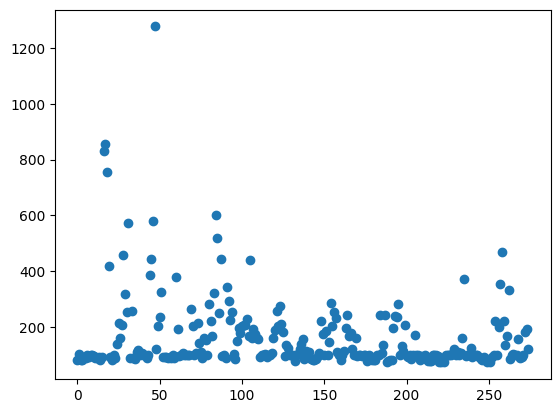

In [136]:
plt.scatter(range(len(nccs_all[mask_temp])), rel_maes_all[mask_temp])

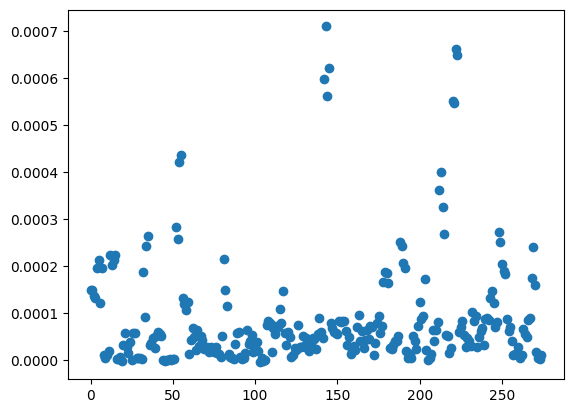

In [137]:
plt.scatter(range(len(nccs_all[mask_temp])), nccs_all[mask_temp])

In [138]:
np.average([rel for rel in rel_maes_all if rel is not None])

159.94475605819528

In [139]:
np.average([ncc for ncc in nccs_all if ncc is not None])

8.828484124040956e-05

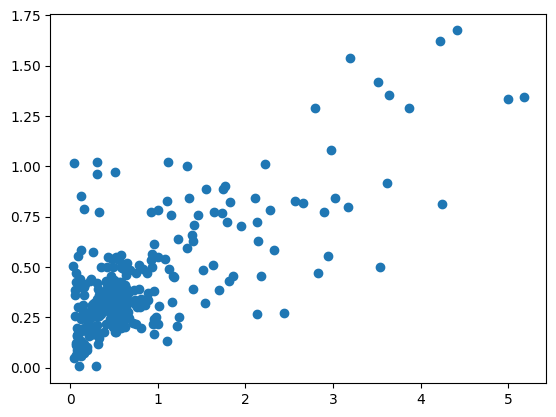

In [140]:
plt.scatter(vol_losses_all[mask_temp], vol_losses_gt_all[mask_temp])

<Axes: >

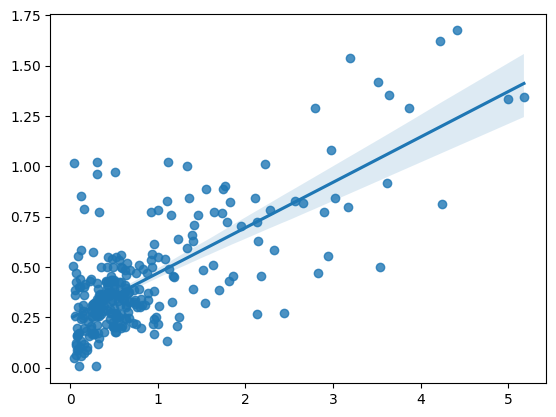

In [141]:
import seaborn as sns
sns.regplot(x = vol_losses_all[mask_temp].astype(float), y = vol_losses_gt_all[mask_temp].astype(float))

<Axes: >

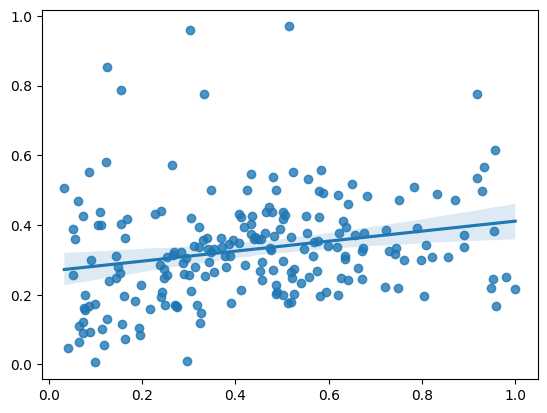

In [142]:
mask_new = np.array([mask_temp[i] and  vol_losses_gt_all.astype(float)[i]<1 and vol_losses_all.astype(float)[i]<1 for i in range(len(vol_losses_gt_all))])
sns.regplot(x = vol_losses_all[mask_new].astype(float), y = vol_losses_gt_all[mask_new].astype(float))

In [143]:
np.corrcoef(vol_losses_all[mask_temp].astype(float), vol_losses_gt_all[mask_temp].astype(float))

array([[1.       , 0.7310962],
       [0.7310962, 1.       ]])

In [144]:
for i in range(len(common_filenames_prof)):
    evaluate_image(common_filenames_prof[i], common_filenames_heat[i], model_temp=model)

Got volume loss gt
Got everything patched
4/4 [==============================] - 9s 2s/step
Predicted everything
Shape of reconstructed:  (1536, 1536)


In [145]:
#for i in range(len(common_filenames_prof)):
#    evaluate_image(common_filenames_prof[i], common_filenames_heat[i], model_temp=model)

Metric2 is type <class 'numpy.ndarray'> and length 275, elements are float64, example 0.7591583483082198
Metric is type <class 'numpy.ndarray'> and length 275, elements are float64, example 1.453068715686703


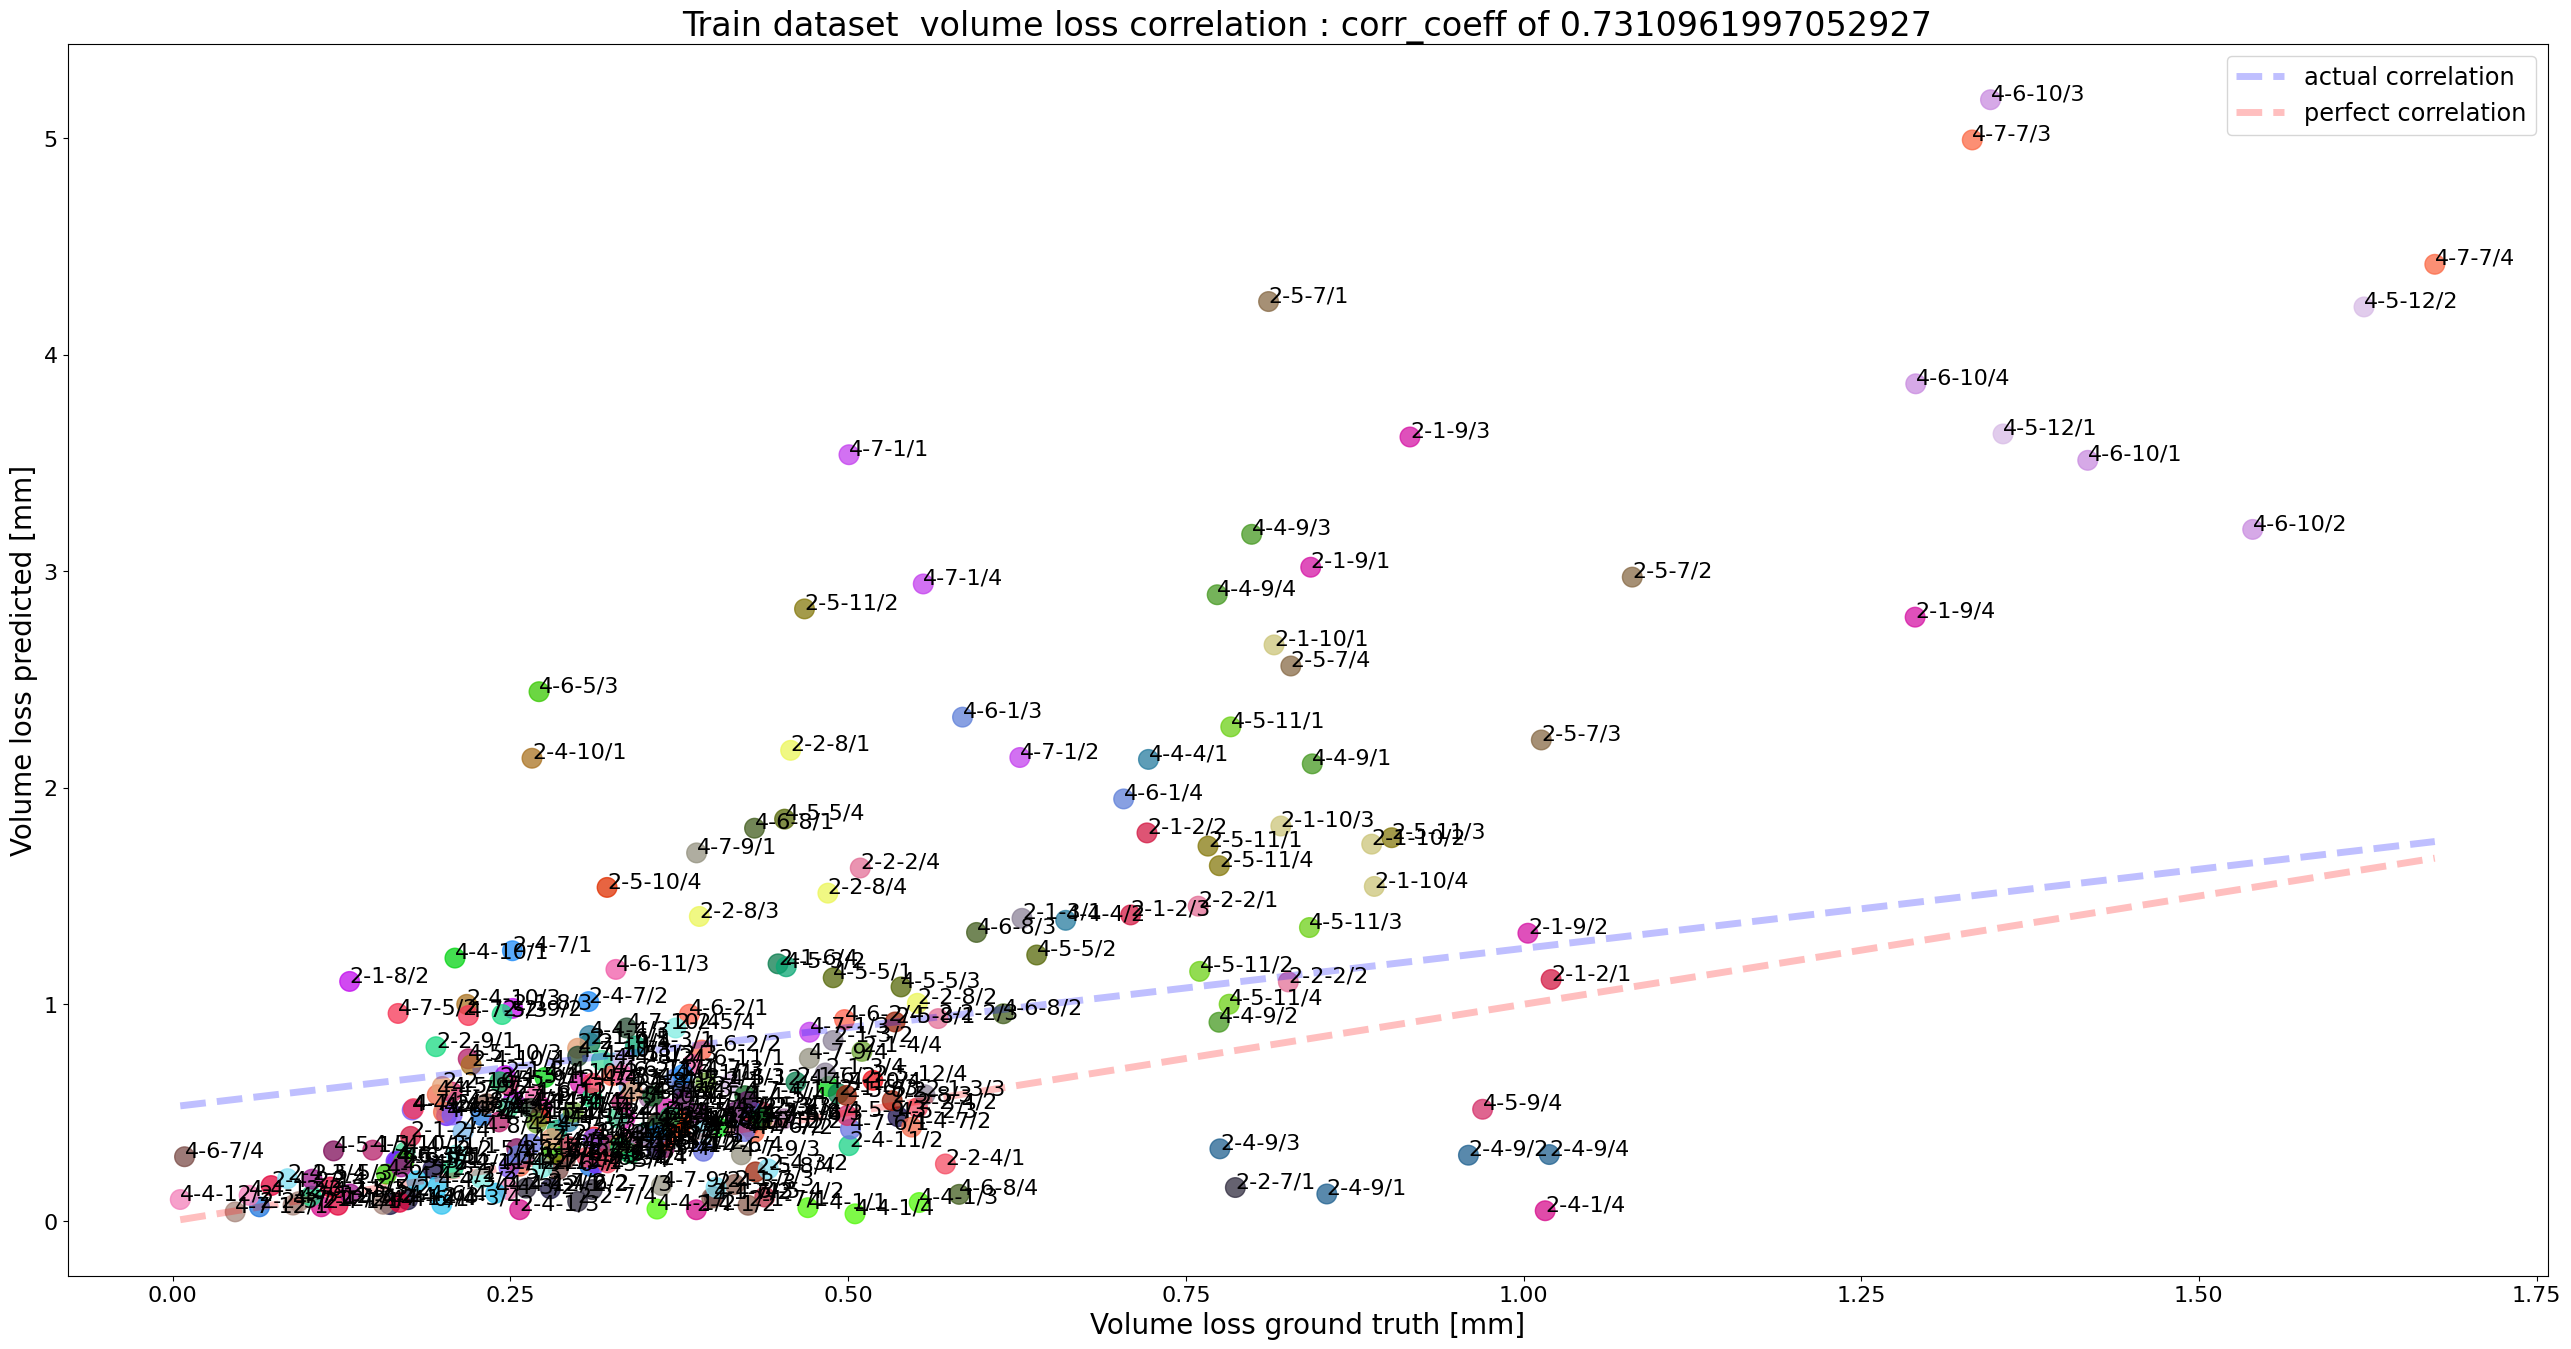

In [146]:
common_filenames_prof = np.array(common_filenames_prof)
samples_material = [common_filenames_prof[i].split('/')[-2] for i in range(len(common_filenames_prof[mask_temp]))]

unique_materials = np.array(list(set(samples_material)))
colors_material = {}
for mat in unique_materials:
    color_temp = "#"+''.join([random.choice('0123456789ABCDEF') for i in range(6)])
    colors_material[mat]=color_temp
    
    
metric = np.array(vol_losses_all.astype(float))[mask_temp]
metric2 = np.array(vol_losses_gt_all.astype(float))[mask_temp]
dataset_name = "Train dataset"
metric_name = " volume loss correlation"#" correlation between predicted and actual volume loss"
filenames = [common_filenames_prof[i].split('/')[-2]+"/"+common_filenames_prof[i].split('/')[-1][:-4] for i in range(len(common_filenames_prof[mask_temp]))]

colors_per_sample = [colors_material[samples_material[sample_index]] for sample_index in range(len(samples_material))]
fig, ax = plt.subplots(figsize=(32, 16))
ax.tick_params(axis='both', which='major', labelsize=16)
plt.ylabel("Volume loss predicted [mm]", fontsize=20)
plt.xlabel("Volume loss ground truth [mm]", fontsize=20)
print("Metric2 is type {} and length {}, elements are {}, example {}".format(type(metric2), len(metric2), metric2.dtype, metric2[0]))
print("Metric is type {} and length {}, elements are {}, example {}".format(type(metric), len(metric), metric.dtype, metric[0]))
coeff = np.corrcoef(metric2, metric)[0, 1]
plt.title(dataset_name+" "+metric_name+" : corr_coeff of "+str(coeff), {'fontsize': 24})
#plt.title(dataset_name+" "+metric_name+" without outliers \n Mean: "+str(metric[metric<350].mean()))
b = np.mean(metric)-coeff*np.mean(metric2)

#ax.set_ylim(-100, 400)
line_real, = ax.plot([np.min(metric2), np.max(metric2)], [np.min(metric2)*coeff+b, np.max(metric2)*coeff+b], 'b--', linewidth=5, alpha=0.25, label = "actual correlation")
line_perfect = ax.plot([np.min(metric2), np.max(metric2)], [np.min(metric2), np.max(metric2)], 'r--', linewidth=5, alpha=0.25, label = "perfect correlation")

ax.legend(fontsize='xx-large')

outliers_flag = True
#FIND OUTLIERS BY METRIC
if outliers_flag:
    # finding the 1st quartile
    q1 = np.quantile(metric, 0.25)

    # finding the 3rd quartile
    q3 = np.quantile(metric, 0.75)
    med = np.median(metric)

    # finding the iqr region
    iqr = q3-q1

    # finding upper and lower whiskers
    upper_bound = q3#+(1.5*iqr)
    lower_bound = q1#-(1.5*iqr)

    outliers_indices = np.array(range(len(metric)))#[(metric <= lower_bound) | (metric >= upper_bound)]


    ax.scatter(y=metric, x=metric2, c=colors_per_sample, s=200, alpha=0.75)
    objects_to_click = []

    for i in range(len(outliers_indices)):
        ax.annotate(filenames[i], (metric2[i], metric[i]), fontsize=16)
    plt.savefig("Vol_loss_correlation.pdf", format="pdf", bbox_inches="tight")

Metric2 is type <class 'numpy.ndarray'> and length 207, elements are float64, example 0.5666438662094824
Metric is type <class 'numpy.ndarray'> and length 207, elements are float64, example 0.9341357377736342


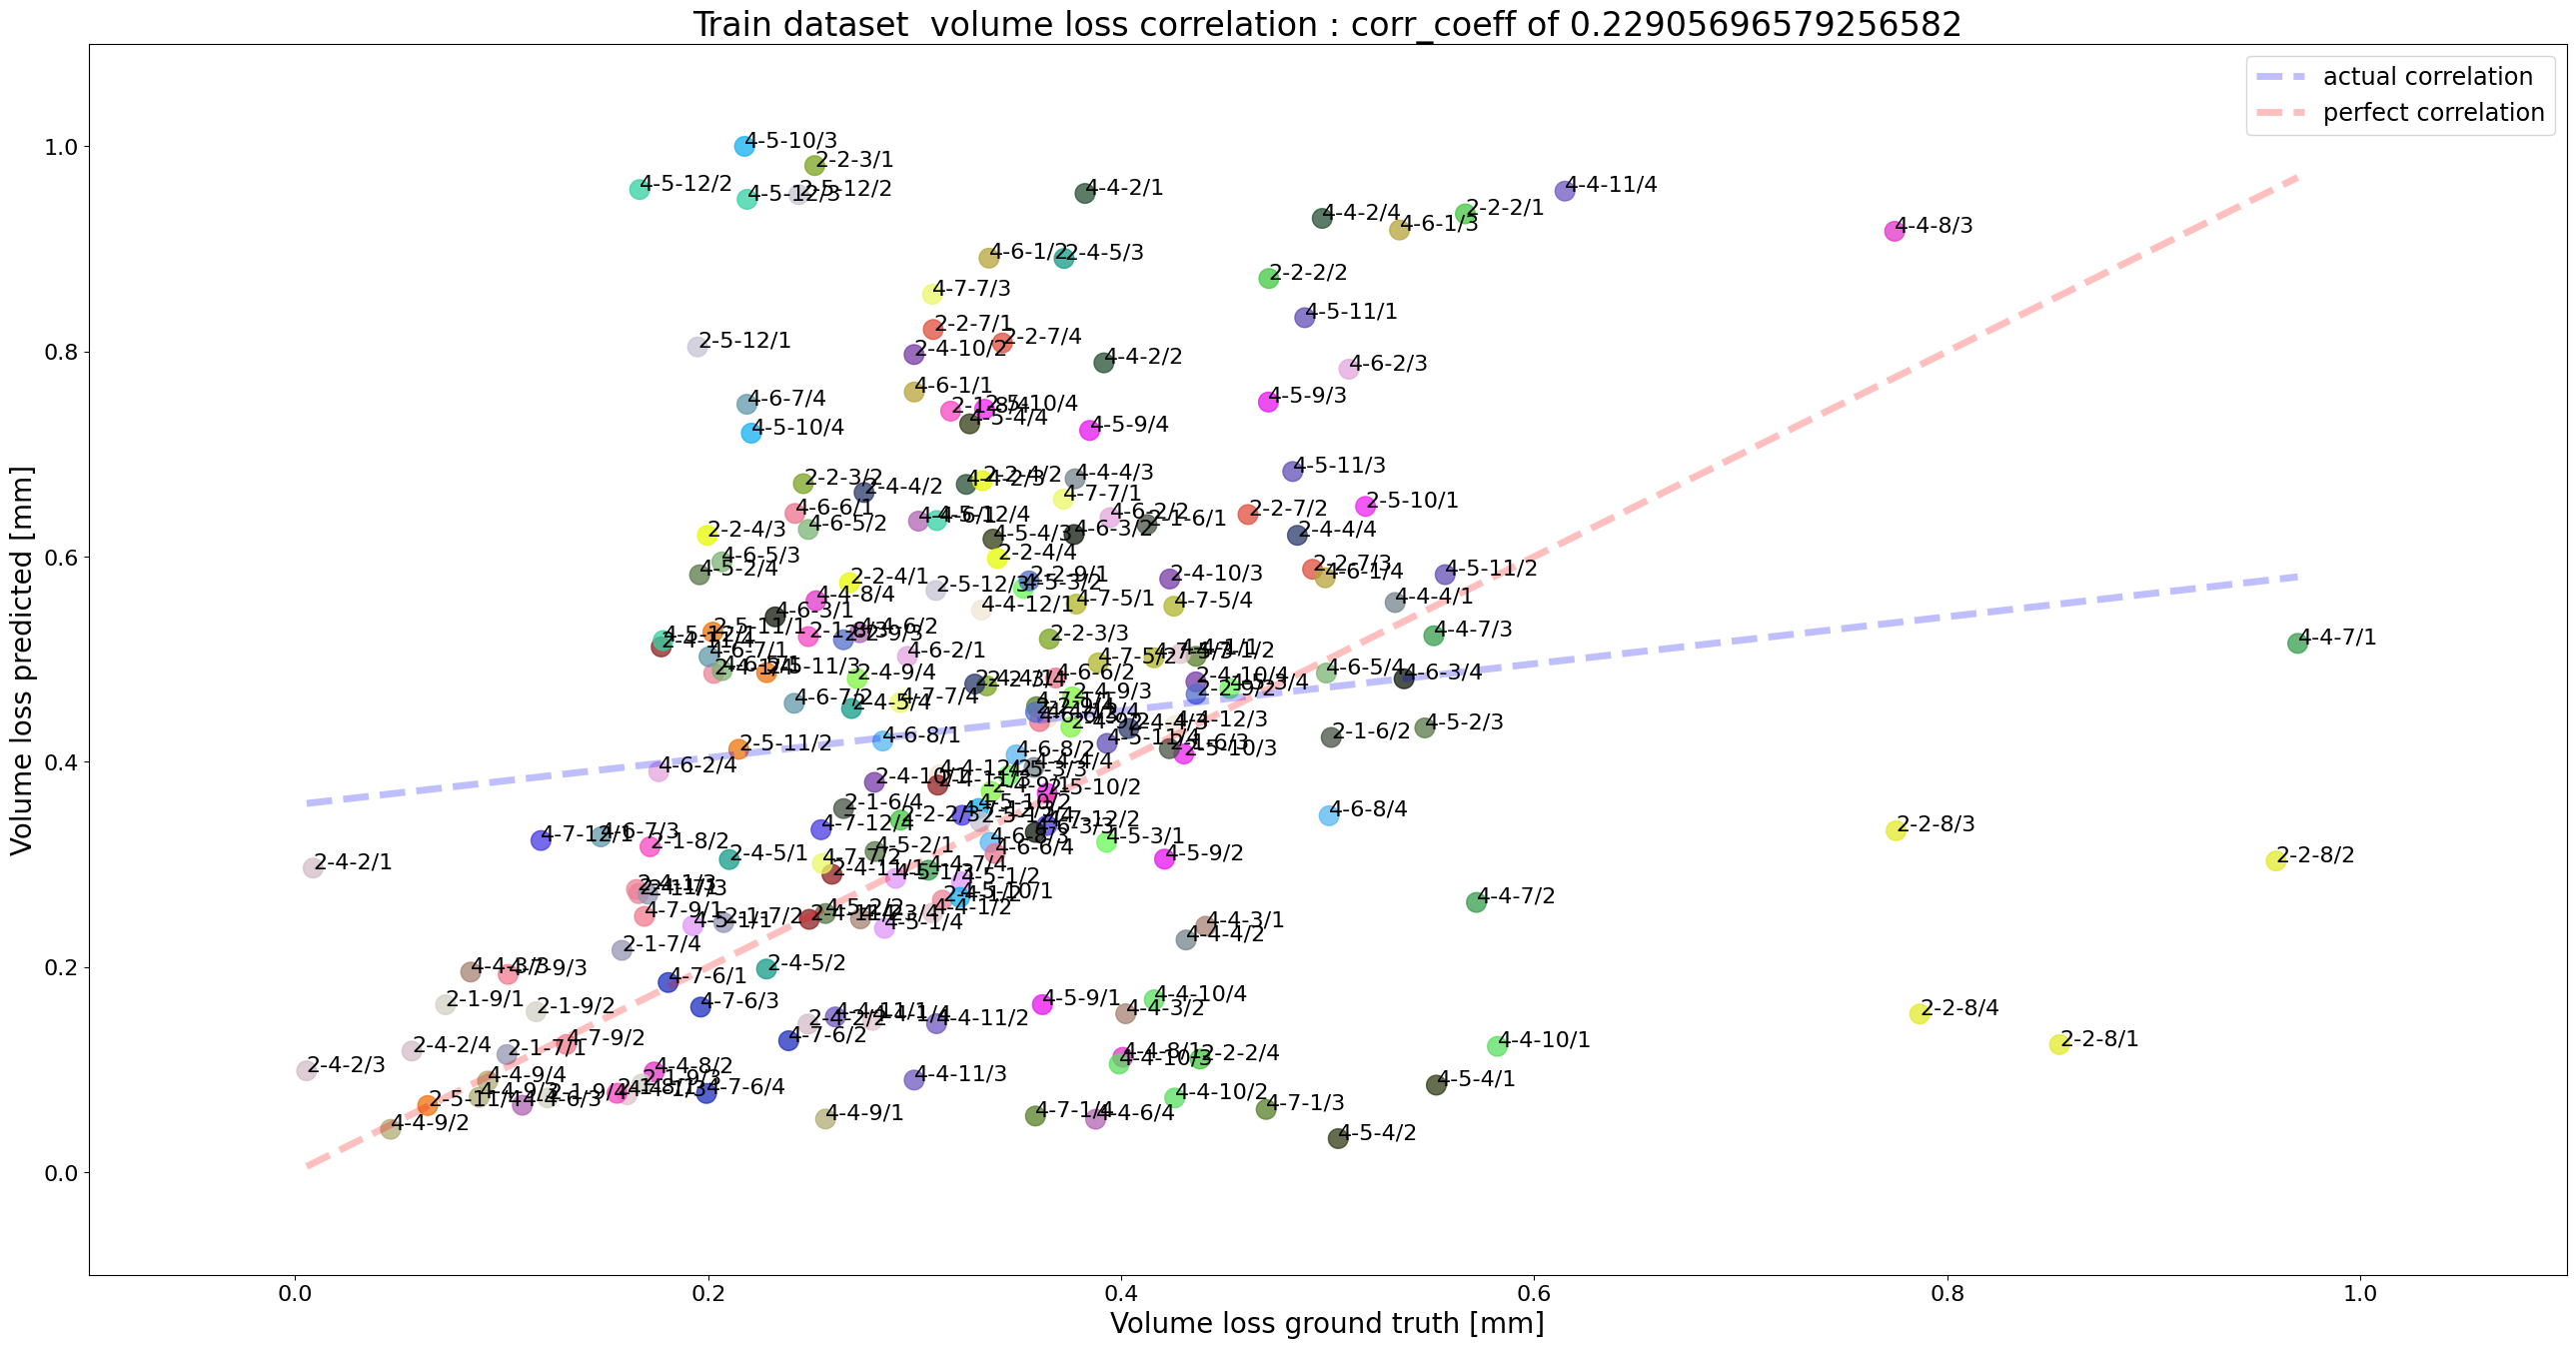

In [147]:
common_filenames_prof = np.array(common_filenames_prof)
no_outlier_mask = [mask_temp[i] and vol_losses_all[i]<1 and vol_losses_gt_all[i]<1 for i in range(len(common_filenames_prof))]

metric = np.array(vol_losses_all.astype(float))[no_outlier_mask]
metric2 = np.array(vol_losses_gt_all.astype(float))[no_outlier_mask]

samples_material = [common_filenames_prof[i].split('/')[-2] for i in range(len(common_filenames_prof[no_outlier_mask]))]

unique_materials = np.array(list(set(samples_material)))
colors_material = {}
for mat in unique_materials:
    color_temp = "#"+''.join([random.choice('0123456789ABCDEF') for i in range(6)])
    colors_material[mat]=color_temp
    
dataset_name = "Train dataset"
metric_name = " volume loss correlation"#" correlation between predicted and actual volume loss"
filenames = [common_filenames_prof[i].split('/')[-2]+"/"+common_filenames_prof[i].split('/')[-1][:-4] for i in range(len(common_filenames_prof[no_outlier_mask]))]

colors_per_sample = [colors_material[samples_material[sample_index]] for sample_index in range(len(samples_material))]
fig, ax = plt.subplots(figsize=(32, 16))
ax.tick_params(axis='both', which='major', labelsize=16)
plt.ylabel("Volume loss predicted [mm]", fontsize=20)
plt.xlabel("Volume loss ground truth [mm]", fontsize=20)
print("Metric2 is type {} and length {}, elements are {}, example {}".format(type(metric2), len(metric2), metric2.dtype, metric2[0]))
print("Metric is type {} and length {}, elements are {}, example {}".format(type(metric), len(metric), metric.dtype, metric[0]))
coeff = np.corrcoef(metric2, metric)[0, 1]
plt.title(dataset_name+" "+metric_name+" : corr_coeff of "+str(coeff), {'fontsize':24})
#plt.title(dataset_name+" "+metric_name+" without outliers \n Mean: "+str(metric[metric<350].mean()))
b = np.mean(metric)-coeff*np.mean(metric2)

ax.set_ylim(-0.1, 1.1)
ax.set_xlim(-0.1, 1.1)
line_real, = ax.plot([np.min(metric2), np.max(metric2)], [np.min(metric2)*coeff+b, np.max(metric2)*coeff+b], 'b--', linewidth=5, alpha=0.25, label = "actual correlation")
line_perfect = ax.plot([np.min(metric2), np.max(metric2)], [np.min(metric2), np.max(metric2)], 'r--', linewidth=5, alpha=0.25, label = "perfect correlation")

ax.legend(fontsize='xx-large')

outliers_flag = True
#FIND OUTLIERS BY METRIC
if outliers_flag:
    # finding the 1st quartile
    q1 = np.quantile(metric, 0.25)

    # finding the 3rd quartile
    q3 = np.quantile(metric, 0.75)
    med = np.median(metric)

    # finding the iqr region
    iqr = q3-q1

    # finding upper and lower whiskers
    upper_bound = q3#+(1.5*iqr)
    lower_bound = q1#-(1.5*iqr)

    outliers_indices = np.array(range(len(metric)))#[(metric <= lower_bound) | (metric >= upper_bound)]


    ax.scatter(y=metric, x=metric2, c=colors_per_sample, s=200, alpha=0.75)
    objects_to_click = []

    for i in range(len(outliers_indices)):
        ax.annotate(filenames[i], (metric2[i], metric[i]), fontsize=16)
    plt.savefig("Vol_loss_correlation_no_outliers.pdf", format="pdf", bbox_inches="tight")

Metric2 is type <class 'numpy.ndarray'> and length 275, elements are int64, example 0
Metric is type <class 'numpy.ndarray'> and length 275, elements are float64, example 91.4052211801212


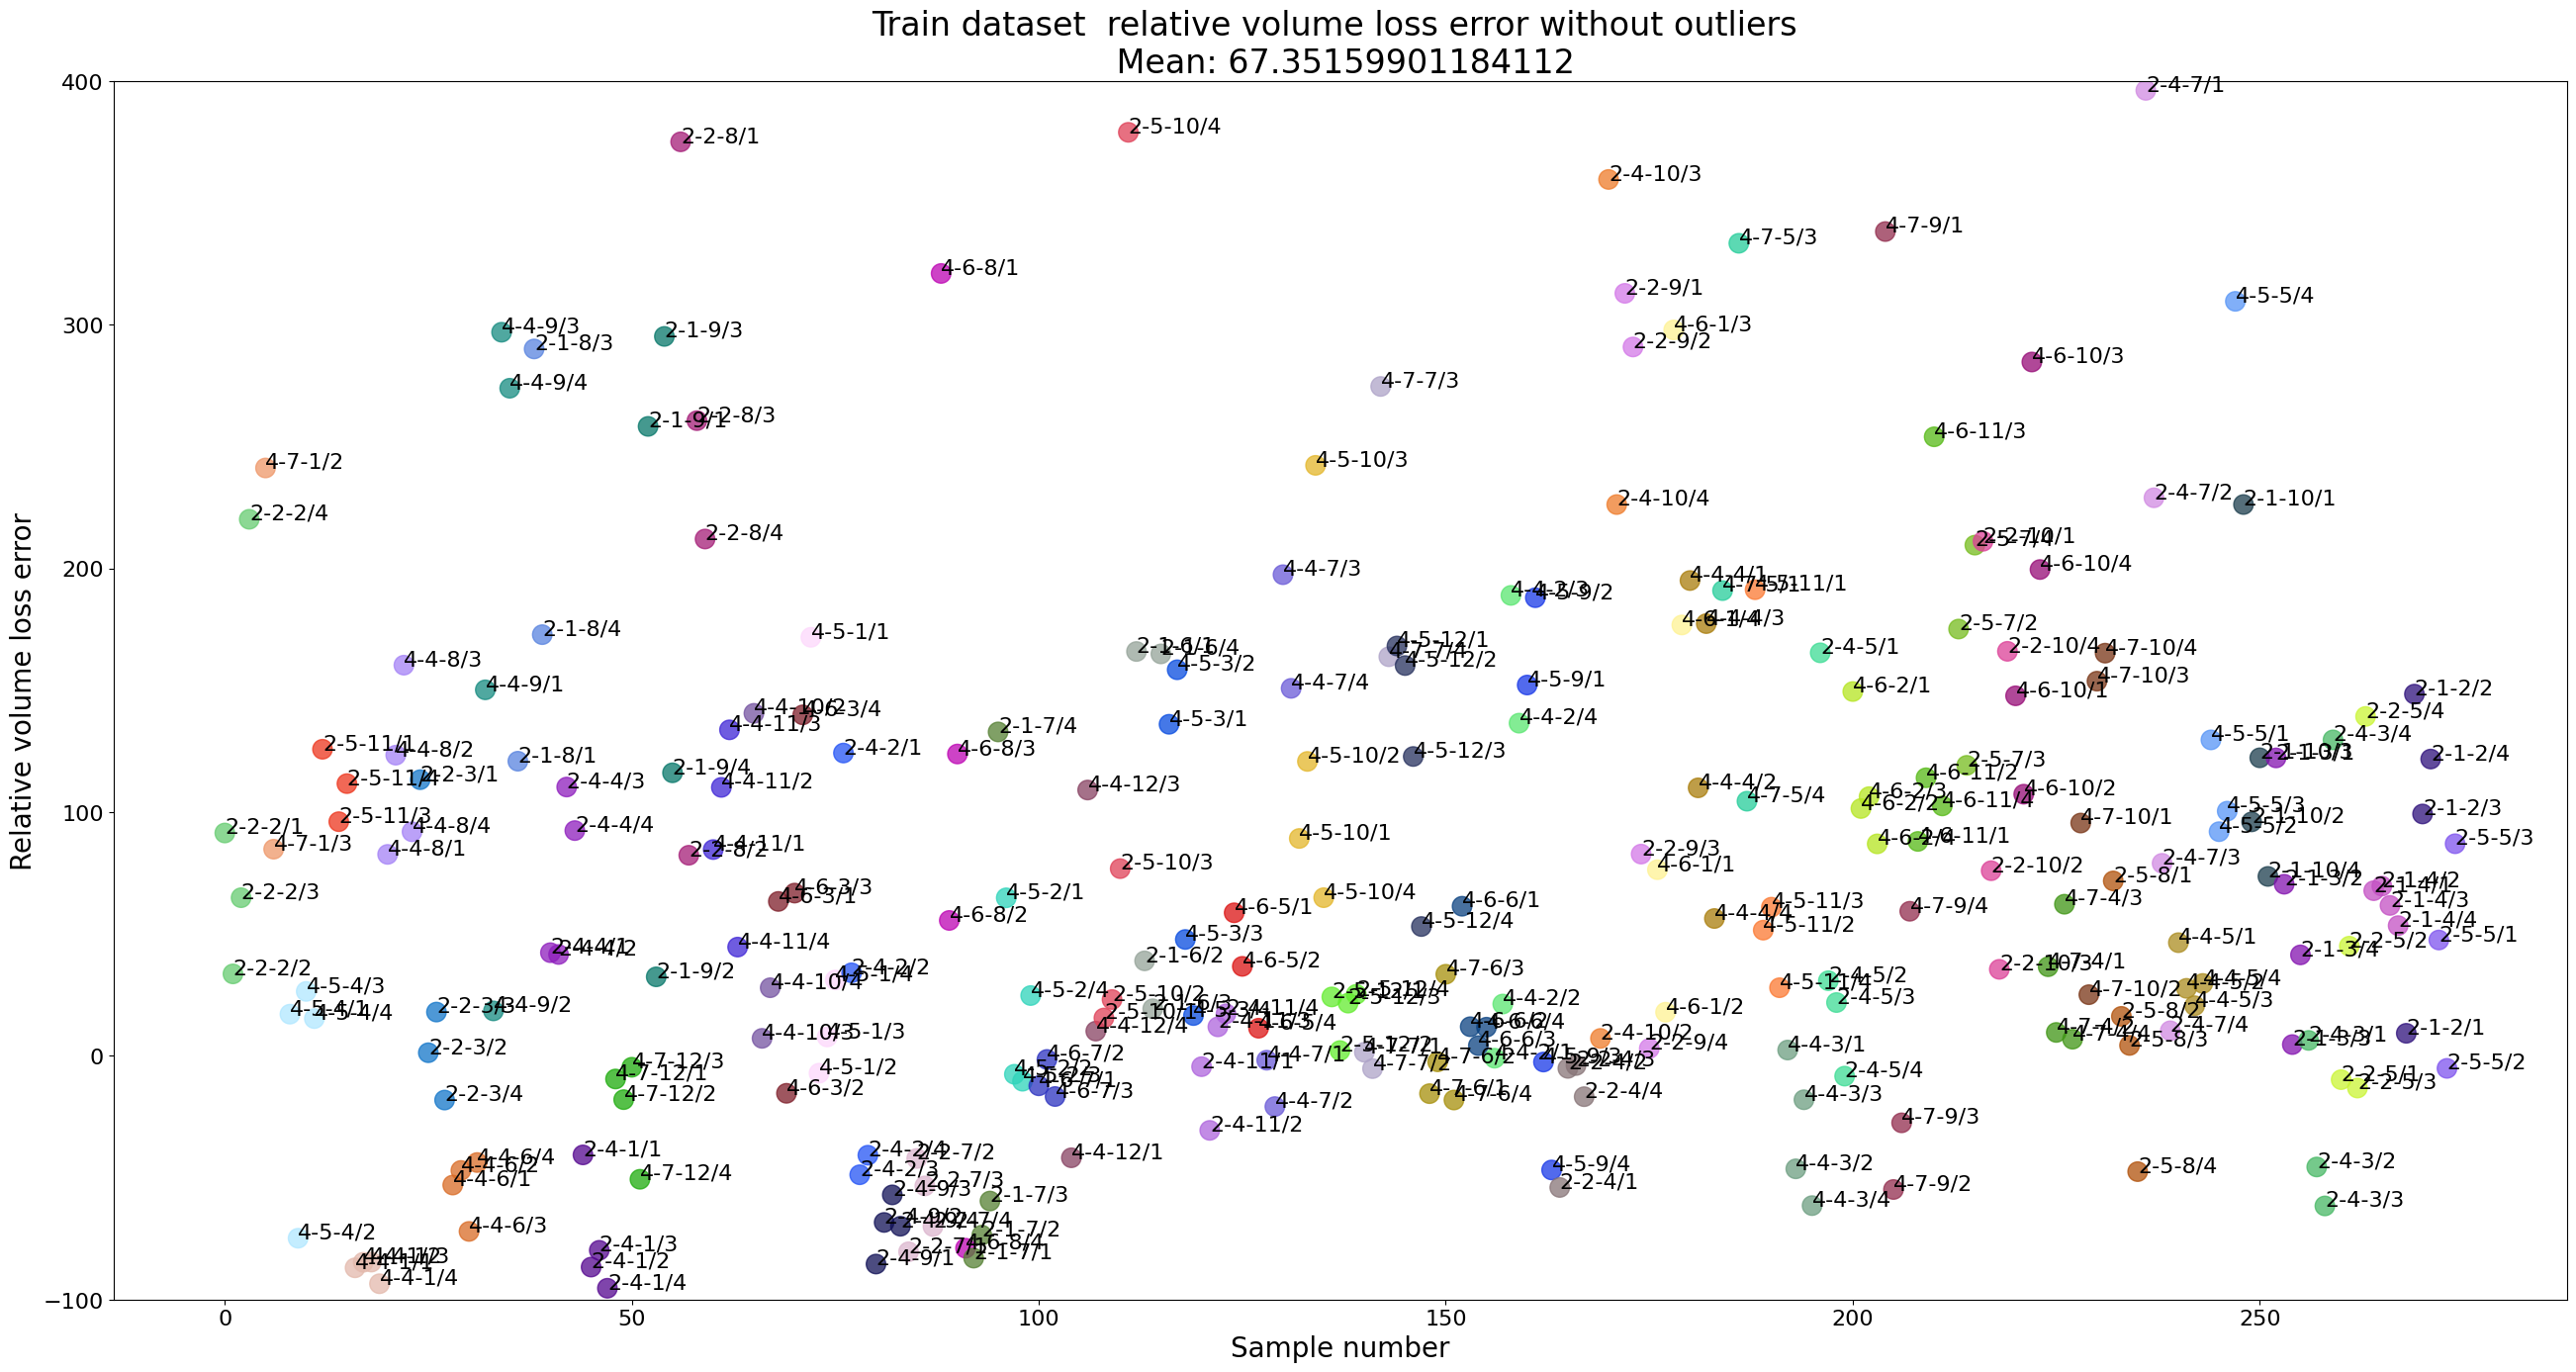

In [148]:
common_filenames_prof = np.array(common_filenames_prof)
samples_material = [common_filenames_prof[i].split('/')[-2] for i in range(len(common_filenames_prof[mask_temp]))]

unique_materials = np.array(list(set(samples_material)))
colors_material = {}
for mat in unique_materials:
    color_temp = "#"+''.join([random.choice('0123456789ABCDEF') for i in range(6)])
    colors_material[mat]=color_temp
    
    
metric = np.array([100*(vol_losses_all[mask_temp][i]-vol_losses_gt_all[mask_temp][i])/vol_losses_gt_all[mask_temp][i] for i in range(len(vol_losses_gt_all[mask_temp]))])#np.array(rel_maes_all.astype(float))[mask_temp]#np.array(vol_losses_all.astype(float))[mask_temp]
metric2 = np.array(range(len(common_filenames_prof[mask_temp])))#np.array(vol_losses_gt_all.astype(float))[mask_temp]
dataset_name = "Train dataset"
metric_name = " relative volume loss error"#" correlation between predicted and actual volume loss"
filenames = [common_filenames_prof[i].split('/')[-2]+"/"+common_filenames_prof[i].split('/')[-1][:-4] for i in range(len(common_filenames_prof[mask_temp]))]

colors_per_sample = [colors_material[samples_material[sample_index]] for sample_index in range(len(samples_material))]
fig, ax = plt.subplots(figsize=(32, 16))
ax.tick_params(axis='both', which='major', labelsize=16)
plt.ylabel("Relative volume loss error", fontsize=20)#plt.ylabel("Volume loss predicted", fontsize=20)
plt.xlabel("Sample number", fontsize=20)#plt.xlabel("Volume loss ground truth", fontsize=20)
print("Metric2 is type {} and length {}, elements are {}, example {}".format(type(metric2), len(metric2), metric2.dtype, metric2[0]))
print("Metric is type {} and length {}, elements are {}, example {}".format(type(metric), len(metric), metric.dtype, metric[0]))
coeff = np.corrcoef(metric2, metric)[0, 1]
#plt.title(dataset_name+" "+metric_name+" : corr_coeff of "+str(coeff))
plt.title(dataset_name+" "+metric_name+" without outliers \n Mean: "+str(metric[metric<350].mean()), {'fontsize':24})
b = np.mean(metric)-coeff*np.mean(metric2)

ax.set_ylim(-100, 400)
#ax.plot([np.min(metric2), np.max(metric2)], [np.min(metric2)*coeff+b, np.max(metric2)*coeff+b], 'b--', linewidth=5, alpha=0.25)

outliers_flag = True
#FIND OUTLIERS BY METRIC
if outliers_flag:
    # finding the 1st quartile
    q1 = np.quantile(metric, 0.25)

    # finding the 3rd quartile
    q3 = np.quantile(metric, 0.75)
    med = np.median(metric)

    # finding the iqr region
    iqr = q3-q1

    # finding upper and lower whiskers
    upper_bound = q3#+(1.5*iqr)
    lower_bound = q1#-(1.5*iqr)

    outliers_indices = np.array(range(len(metric)))#[(metric <= lower_bound) | (metric >= upper_bound)]


    ax.scatter(y=metric, x=metric2, c=colors_per_sample, s=200, alpha=0.75)
    objects_to_click = []

    for i in range(len(outliers_indices)):
        ax.annotate(filenames[i], (metric2[i], metric[i]), fontsize=16)
    plt.savefig("Vol_loss_relative_no_outliers.pdf", format="pdf", bbox_inches="tight")

Metric2 is type <class 'numpy.ndarray'> and length 275, elements are int64, example 0
Metric is type <class 'numpy.ndarray'> and length 275, elements are float64, example 91.4052211801212


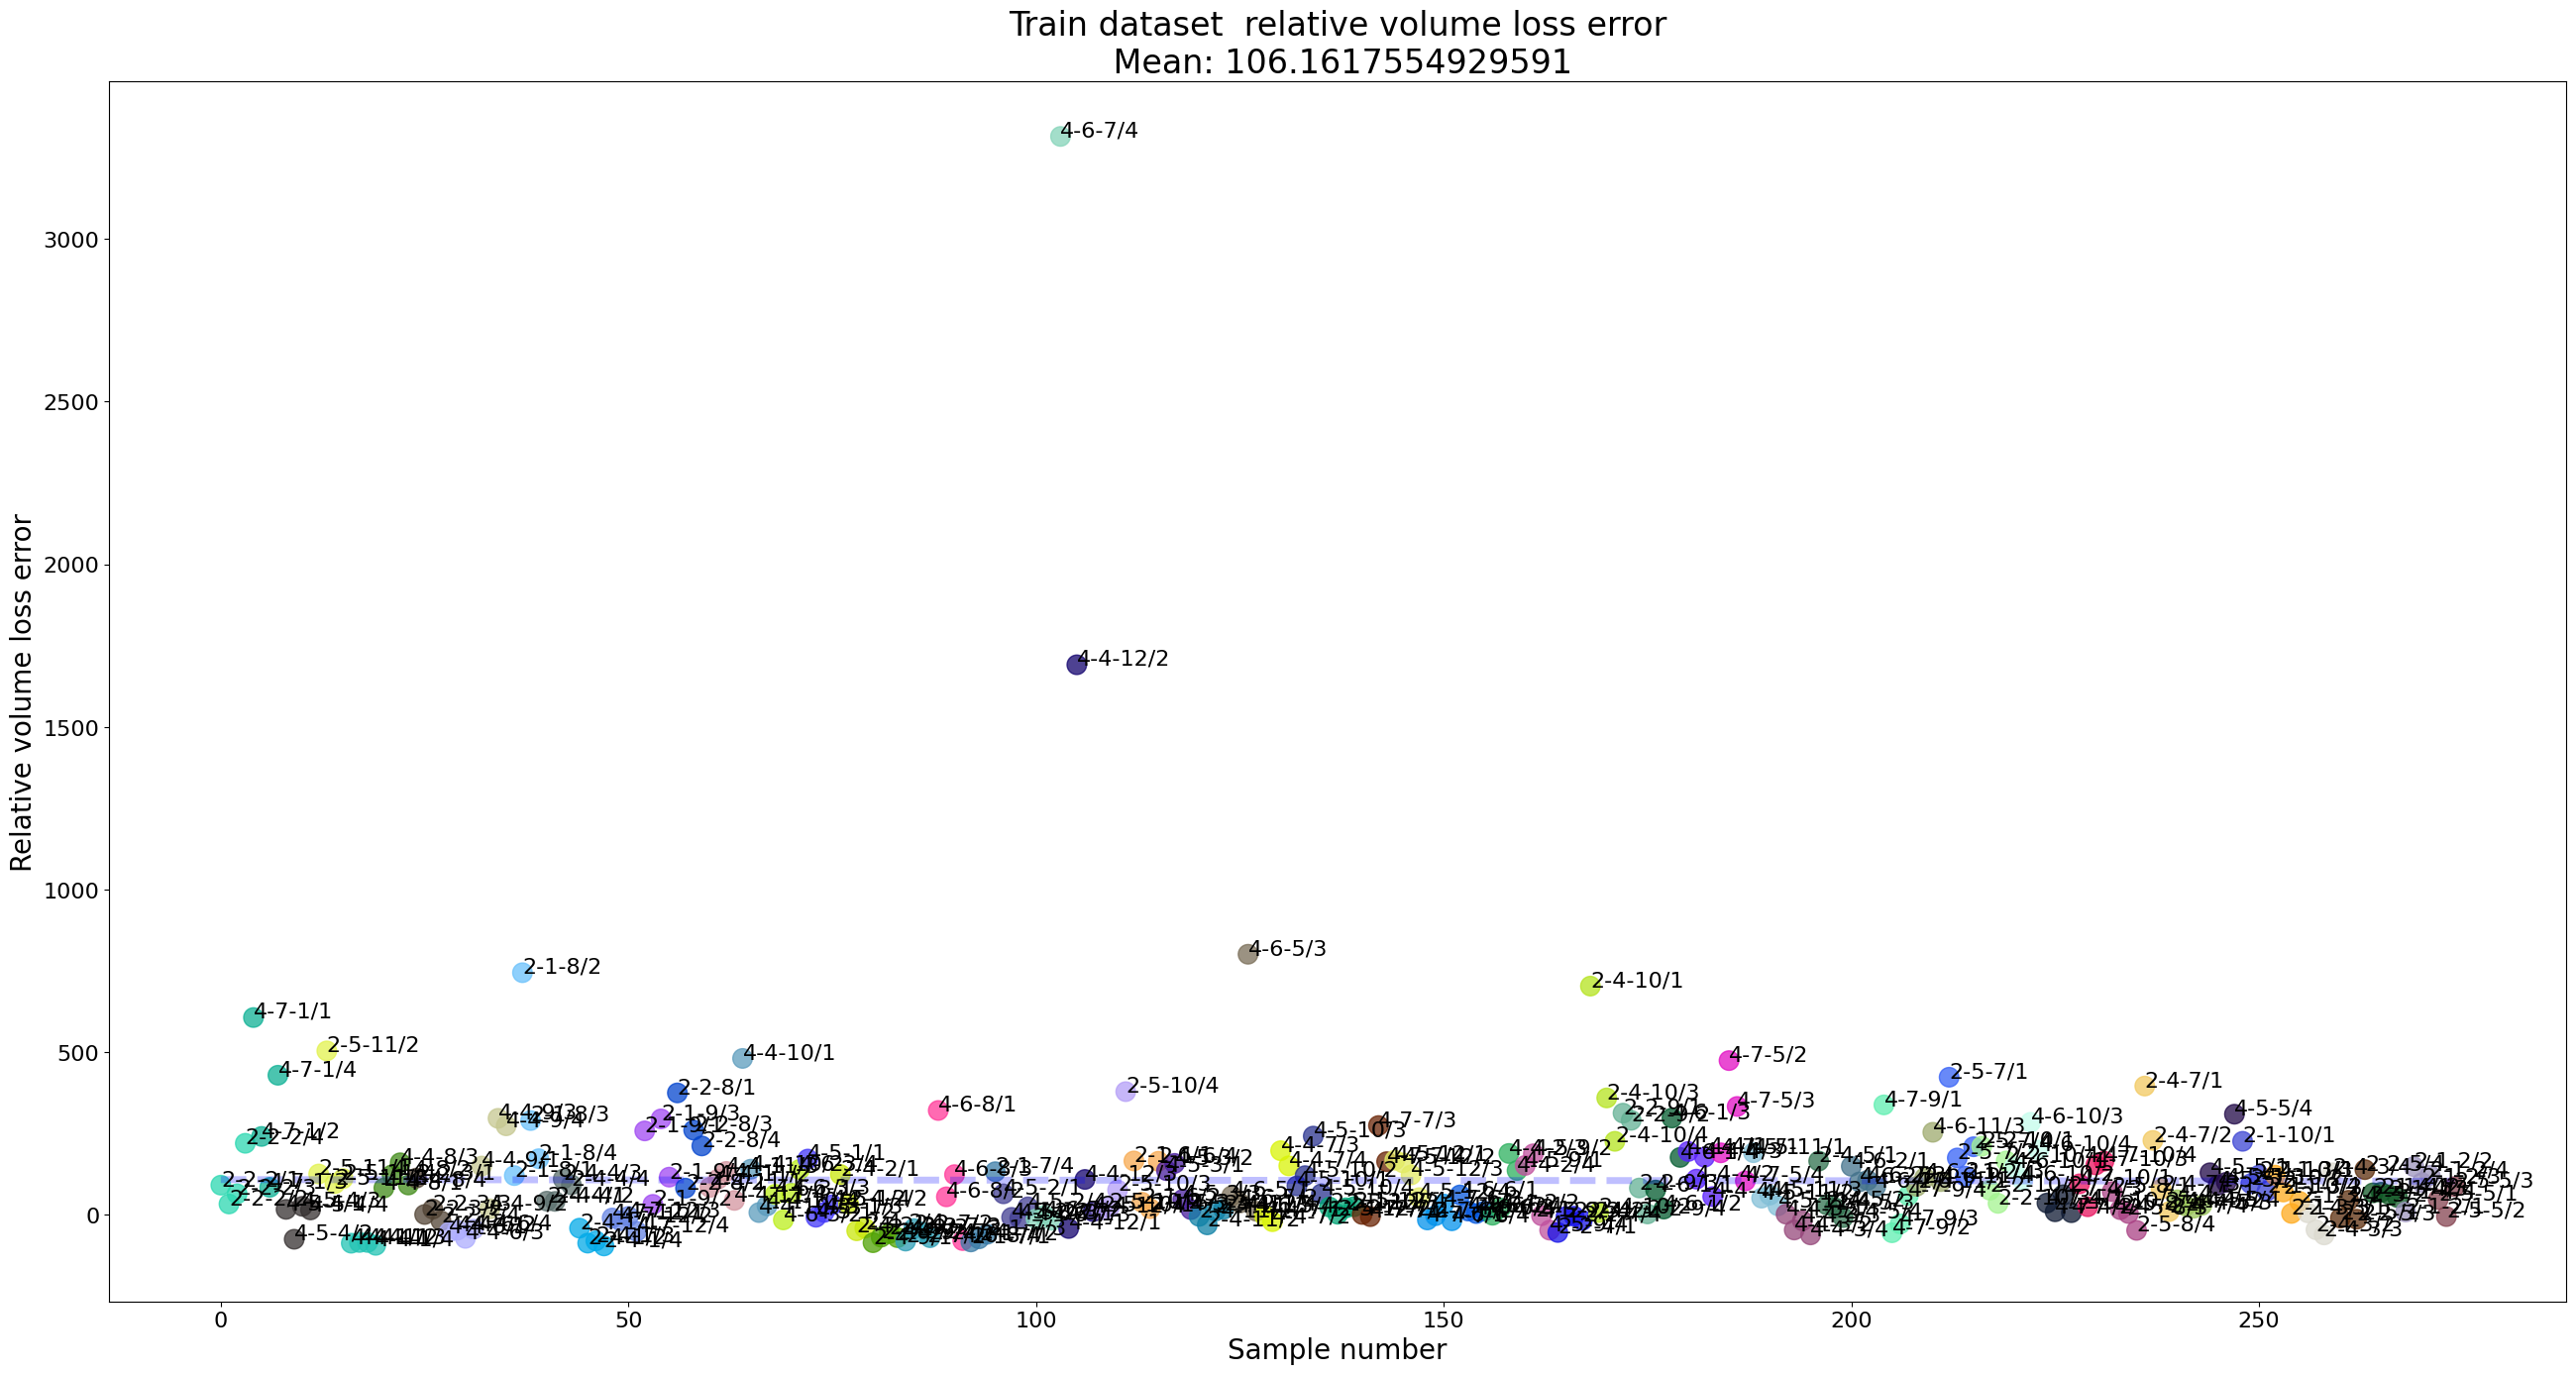

In [149]:
common_filenames_prof = np.array(common_filenames_prof)
samples_material = [common_filenames_prof[i].split('/')[-2] for i in range(len(common_filenames_prof[mask_temp]))]

unique_materials = np.array(list(set(samples_material)))
colors_material = {}
for mat in unique_materials:
    color_temp = "#"+''.join([random.choice('0123456789ABCDEF') for i in range(6)])
    colors_material[mat]=color_temp
    
    
metric = np.array([100*(vol_losses_all[mask_temp][i]-vol_losses_gt_all[mask_temp][i])/vol_losses_gt_all[mask_temp][i] for i in range(len(vol_losses_gt_all[mask_temp]))])#np.array(rel_maes_all.astype(float))[mask_temp]#np.array(vol_losses_all.astype(float))[mask_temp]
metric2 = np.array(range(len(common_filenames_prof[mask_temp])))#np.array(vol_losses_gt_all.astype(float))[mask_temp]
dataset_name = "Train dataset"
metric_name = " relative volume loss error"#" correlation between predicted and actual volume loss"
filenames = [common_filenames_prof[i].split('/')[-2]+"/"+common_filenames_prof[i].split('/')[-1][:-4] for i in range(len(common_filenames_prof[mask_temp]))]

colors_per_sample = [colors_material[samples_material[sample_index]] for sample_index in range(len(samples_material))]
fig, ax = plt.subplots(figsize=(32, 16))
ax.tick_params(axis='both', which='major', labelsize=16)
plt.ylabel("Relative volume loss error", fontsize=20)#plt.ylabel("Volume loss predicted", fontsize=20)
plt.xlabel("Sample number", fontsize=20)#plt.xlabel("Volume loss ground truth", fontsize=20)
print("Metric2 is type {} and length {}, elements are {}, example {}".format(type(metric2), len(metric2), metric2.dtype, metric2[0]))
print("Metric is type {} and length {}, elements are {}, example {}".format(type(metric), len(metric), metric.dtype, metric[0]))
coeff = np.corrcoef(metric2, metric)[0, 1]
#plt.title(dataset_name+" "+metric_name+" : corr_coeff of "+str(coeff))
plt.title(dataset_name+" "+metric_name+"\n Mean: "+str(metric.mean()), {'fontsize':24})
b = np.mean(metric)-coeff*np.mean(metric2)

#ax.set_ylim(-100, 400)
ax.plot([np.min(metric2), np.max(metric2)], [np.min(metric2)*coeff+b, np.max(metric2)*coeff+b], 'b--', linewidth=5, alpha=0.25)

outliers_flag = True
#FIND OUTLIERS BY METRIC
if outliers_flag:
    # finding the 1st quartile
    q1 = np.quantile(metric, 0.25)

    # finding the 3rd quartile
    q3 = np.quantile(metric, 0.75)
    med = np.median(metric)

    # finding the iqr region
    iqr = q3-q1

    # finding upper and lower whiskers
    upper_bound = q3#+(1.5*iqr)
    lower_bound = q1#-(1.5*iqr)

    outliers_indices = np.array(range(len(metric)))#[(metric <= lower_bound) | (metric >= upper_bound)]


    ax.scatter(y=metric, x=metric2, c=colors_per_sample, s=200, alpha=0.75)
    objects_to_click = []

    for i in range(len(outliers_indices)):
        ax.annotate(filenames[i], (metric2[i], metric[i]), fontsize=16)
    plt.savefig("Vol_loss_relative.pdf", format="pdf", bbox_inches="tight")

In [150]:
common_filenames_prof = np.array(common_filenames_prof)
common_filenames_heat = np.array(common_filenames_heat)
for i in range(len(common_filenames_prof[mask_temp])): 
    material_temp_prof = common_filenames_prof[mask_temp][i].split('/')[-2]
    material_temp_heat = common_filenames_heat[mask_temp][i].split('/')[-2]
    sample_temp_prof = common_filenames_prof[mask_temp][i].split('/')[-1][:-4]
    sample_temp_heat = common_filenames_heat[mask_temp][i].split('/')[-1][:-4]
    if material_temp_prof!=material_temp_heat:
        print("Material prof: {} and material heat: {}, prof name: {} and i = {}".format(material_temp_prof, material_temp_heat, common_filenames_prof[mask_temp][i], i))
    if sample_temp_prof!=sample_temp_heat:
        print("Sample prof: {} and sample heat: {}, prof name: {} and i = {}".format(sample_temp_prof, sample_temp_heat,common_filenames_prof[mask_temp][i], i))

In [151]:
common_filenames_prof[mask_temp][239:]

array(['/Volumes/Expansion/AI2 results/AI2 results/2-4/before/profilometer/2-4-6/4.png',
       '/Volumes/Expansion/AI2 results/AI2 results/2-2/before/profilometer/2-2-6/1.png',
       '/Volumes/Expansion/AI2 results/AI2 results/2-2/before/profilometer/2-2-6/2.png',
       '/Volumes/Expansion/AI2 results/AI2 results/2-2/before/profilometer/2-2-6/3.png',
       '/Volumes/Expansion/AI2 results/AI2 results/2-2/before/profilometer/2-2-6/4.png',
       '/Volumes/Expansion/AI2 results/AI2 results/2-4/before/profilometer/2-4-8/1.png',
       '/Volumes/Expansion/AI2 results/AI2 results/2-4/before/profilometer/2-4-8/2.png',
       '/Volumes/Expansion/AI2 results/AI2 results/2-4/before/profilometer/2-4-8/3.png',
       '/Volumes/Expansion/AI2 results/AI2 results/2-4/before/profilometer/2-4-8/4.png',
       '/Volumes/Expansion/AI2 results/AI2 results/4-6/before/profilometer/4-6-9/1.png',
       '/Volumes/Expansion/AI2 results/AI2 results/4-6/before/profilometer/4-6-9/2.png',
       '/Volumes/Expa

In [152]:
common_filenames_heat[mask_temp][239:]

array(['/Volumes/Expansion/AI2 results/AI2 results/2-4/after/heatmap raw data/2-4-6/4.csv',
       '/Volumes/Expansion/AI2 results/AI2 results/2-2/after/heatmap raw data/2-2-6/1.csv',
       '/Volumes/Expansion/AI2 results/AI2 results/2-2/after/heatmap raw data/2-2-6/2.csv',
       '/Volumes/Expansion/AI2 results/AI2 results/2-2/after/heatmap raw data/2-2-6/3.csv',
       '/Volumes/Expansion/AI2 results/AI2 results/2-2/after/heatmap raw data/2-2-6/4.csv',
       '/Volumes/Expansion/AI2 results/AI2 results/2-4/after/heatmap raw data/2-4-8/1.csv',
       '/Volumes/Expansion/AI2 results/AI2 results/2-4/after/heatmap raw data/2-4-8/2.csv',
       '/Volumes/Expansion/AI2 results/AI2 results/2-4/after/heatmap raw data/2-4-8/3.csv',
       '/Volumes/Expansion/AI2 results/AI2 results/2-4/after/heatmap raw data/2-4-8/4.csv',
       '/Volumes/Expansion/AI2 results/AI2 results/4-6/after/heatmap raw data/4-6-9/1.csv',
       '/Volumes/Expansion/AI2 results/AI2 results/4-6/after/heatmap raw data/4-

In [80]:
del common_filenames_heat[mask_temp][-12]

ValueError: cannot delete array elements

In [83]:
np.array(range(len(common_filenames_heat)))[mask_temp][-34]

336

In [84]:
np.array(range(len(common_filenames_heat)))[mask_temp][-12]

363

In [85]:
common_filenames_heat = np.delete(common_filenames_heat, 363)
common_filenames_prof = np.delete(common_filenames_prof, 336)